# v18 Scene-Graph Score Analysis

This notebook inspects the `data/raw/v18/` dataset used in this repository,
adapts to the actual COCO-style annotation schema present in the repo, and
computes a geometry-derived scene-graph score for each image.

Important repo-aware notes:
- The repo already provides path helpers in `src/core/paths.py`.
- The repo already provides COCO annotation utilities in
  `src/core/data/annotations.py`.
- The repo does not appear to define a canonical scene-graph score built from
  IoU, proximity, scale, and direction. The scoring layer below therefore
  isolates that logic behind one function so it can be swapped easily if a
  project-specific formula exists elsewhere.



In [1]:
from __future__ import annotations

import json
import math
import os
import random
import sys
import warnings
from collections import Counter
from itertools import combinations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

try:
    from scipy import stats
except Exception:
    stats = None

try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
except Exception:
    TSNE = None
    StandardScaler = None

try:
    import umap
except Exception:
    umap = None


def _resolve_repo_root() -> Path:
    """Resolve the repository root from notebook or script execution context."""
    try:
        from src.core.paths import repo_root as _repo_root

        return _repo_root()
    except Exception:
        start = Path.cwd().resolve()
        for candidate in [start, *start.parents]:
            if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
                return candidate
        raise RuntimeError("Could not resolve repository root from the current environment.")


REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.core.data.annotations import (  # noqa: E402
    coco_bbox_to_xyxy,
    index_annotations,
    load_coco_annotations,
)
from src.core.normalization import raw_to_norm_numpy  # noqa: E402
from src.core.paths import repo_root as repo_root_from_pkg  # noqa: E402
from src.core.paths import v18_root  # noqa: E402

assert repo_root_from_pkg() == REPO_ROOT

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.style.use("default")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 120

DATA_ROOT = v18_root()
CACHE_DIR = REPO_ROOT / "data" / "cache" / "scene_graph_score_analysis"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "val", "test")
MAX_IMAGES_TO_SCAN = None
MAX_OBJECTS_FOR_PAIRWISE = 40
TOP_K = 8
SAMPLE_PER_BIN = 4
MAX_CLASS_PAIRS = 12
TOP_EDGES_TO_DRAW = 5
USE_CACHE = True
FORCE_RECOMPUTE = False
ROBUSTNESS_SAMPLE_SIZE = 1000
EMBEDDING_MAX_POINTS = 2500

SCORE_COMPONENT_WEIGHTS = {
    "iou": 1.0,
    "proximity": 1.0,
    "scale": 1.0,
    "direction": 1.0,
}
ENABLE_COMPONENTS = {
    "iou": True,
    "proximity": True,
    "scale": True,
    "direction": True,
}
GRAPH_SCORE_NORMALIZATION = "mean"  # "sum" or "mean"
OVERLAP_IOU_THRESHOLD = 0.05
PROXIMITY_LENGTH_SCALE = 0.35
PERTURBATION_STD_FRACTION = 0.03

display(
    Markdown(
        f"""
**Environment**

- `REPO_ROOT`: `{REPO_ROOT}`
- `DATA_ROOT`: `{DATA_ROOT}`
- `SPLITS`: `{SPLITS}`
- `GRAPH_SCORE_NORMALIZATION`: `{GRAPH_SCORE_NORMALIZATION}`
- `SEED`: `{SEED}`
"""
    )
)




**Environment**

- `REPO_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial`
- `DATA_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/v18`
- `SPLITS`: `('train', 'val', 'test')`
- `GRAPH_SCORE_NORMALIZATION`: `mean`
- `SEED`: `7`


## Dataset and annotation discovery

The next cells inspect the v18 layout instead of assuming split health or
annotation schema details. This matters in this repo because `val` currently
contains many annotations whose corresponding `.npy` files are not present
locally.



In [2]:
def discover_v18_layout(data_root: Path, splits: Sequence[str]) -> pd.DataFrame:
    """Inspect likely v18 split locations and summarize what is present."""
    rows = []
    for split in splits:
        split_dir = data_root / split
        ann_path = split_dir / "annotations.json"
        image_files = sorted(split_dir.glob("*.npy")) if split_dir.exists() else []

        row = {
            "split": split,
            "split_dir": split_dir,
            "split_exists": split_dir.exists(),
            "annotation_path": ann_path,
            "annotation_exists": ann_path.exists(),
            "npy_files": len(image_files),
            "sample_files": [p.name for p in image_files[:3]],
        }

        if ann_path.exists():
            coco = load_coco_annotations(ann_path)
            row["annotation_top_keys"] = list(coco.keys())
            row["n_images_in_json"] = len(coco.get("images", []))
            row["n_annotations"] = len(coco.get("annotations", []))
            row["n_categories"] = len(coco.get("categories", []))
            row["has_relations_key"] = "relations" in coco
            row["sample_image_keys"] = (
                list(coco["images"][0].keys()) if coco.get("images") else []
            )
            row["sample_annotation_keys"] = (
                list(coco["annotations"][0].keys()) if coco.get("annotations") else []
            )
            row["sample_category_keys"] = (
                list(coco["categories"][0].keys()) if coco.get("categories") else []
            )
            annotated_files = {
                img.get("file_name") for img in coco.get("images", []) if img.get("file_name")
            }
            local_files = {p.name for p in image_files}
            row["matched_files"] = len(annotated_files & local_files)
            row["missing_local_files"] = len(annotated_files - local_files)
            row["unannotated_local_files"] = len(local_files - annotated_files)
        else:
            row["annotation_top_keys"] = []
            row["n_images_in_json"] = 0
            row["n_annotations"] = 0
            row["n_categories"] = 0
            row["has_relations_key"] = False
            row["sample_image_keys"] = []
            row["sample_annotation_keys"] = []
            row["sample_category_keys"] = []
            row["matched_files"] = 0
            row["missing_local_files"] = 0
            row["unannotated_local_files"] = len(image_files)

        rows.append(row)
    return pd.DataFrame(rows)


layout_df = discover_v18_layout(DATA_ROOT, SPLITS)
layout_df



,split,split_dir,split_exists,annotation_path,annotation_exists,npy_files,sample_files,annotation_top_keys,n_images_in_json,n_annotations,n_categories,has_relations_key,sample_image_keys,sample_annotation_keys,sample_category_keys,matched_files,missing_local_files,unannotated_local_files
0,train,/projets/Fbassignana/diffusers_try/flow_matchi...,True,/projets/Fbassignana/diffusers_try/flow_matchi...,True,6725,[sequence-20250131-170405-786683-9834f0-7e367b...,"[info, licenses, categories, images, annotations]",6725,16822,1,False,"[id, width, height, file_name]","[id, image_id, category_id, bbox, area, iscrowd]","[id, name]",6725,0,0
1,val,/projets/Fbassignana/diffusers_try/flow_matchi...,True,/projets/Fbassignana/diffusers_try/flow_matchi...,True,188,[sequence-20250131-170507-975493-9834f0-561c2c...,"[info, licenses, categories, images, annotations]",2289,5947,1,False,"[id, width, height, file_name]","[id, image_id, category_id, bbox, area, iscrowd]","[id, name]",188,2101,0
2,test,/projets/Fbassignana/diffusers_try/flow_matchi...,True,/projets/Fbassignana/diffusers_try/flow_matchi...,True,799,[sequence-20250203-083945-802612-94f5a2-628452...,"[info, licenses, categories, images, annotations]",799,2026,1,False,"[id, width, height, file_name]","[id, image_id, category_id, bbox, area, iscrowd]","[id, name]",799,0,0


In [3]:
for split in SPLITS:
    ann_path = DATA_ROOT / split / "annotations.json"
    if not ann_path.exists():
        print(f"[{split}] Missing annotations.json")
        continue

    coco = load_coco_annotations(ann_path)
    print(f"\n=== {split} ===")
    print("Top-level keys:", list(coco.keys()))
    if coco.get("images"):
        print("Sample image record:")
        print(json.dumps(coco["images"][0], indent=2))
    if coco.get("annotations"):
        print("Sample annotation record:")
        print(json.dumps(coco["annotations"][0], indent=2))
    if coco.get("categories"):
        print("Sample category record:")
        print(json.dumps(coco["categories"][0], indent=2))




=== train ===
Top-level keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Sample image record:
{
  "id": "sequence-20250506-172443-625038-ce2df7-b3a1b450e33e4a74fbfc5e671f1d7d1ca6e184e5ad2429a2be128e63a8c80e6b-11",
  "width": 256,
  "height": 192,
  "file_name": "sequence-20250506-172443-625038-ce2df7-b3a1b450e33e4a74fbfc5e671f1d7d1ca6e184e5ad2429a2be128e63a8c80e6b-11.npy"
}
Sample annotation record:
{
  "id": 0,
  "image_id": "sequence-20250506-172443-625038-ce2df7-b3a1b450e33e4a74fbfc5e671f1d7d1ca6e184e5ad2429a2be128e63a8c80e6b-11",
  "category_id": 0,
  "bbox": [
    51.82524888780376,
    78.57289939880357,
    63.09859205457894,
    59.821992229885524
  ],
  "area": 3774.683483605738,
  "iscrowd": 0
}
Sample category record:
{
  "id": 0,
  "name": "person"
}

=== val ===
Top-level keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Sample image record:
{
  "id": "sequence-20250811-160109-746626-9852a5-bf6f27428ee975d3d94669d6d18c63292f7bc01c7e03d1bd0

## Loader layer

The loader layer below reuses the repo's COCO helpers and then adapts the
records into explicit per-image and per-object tables that the scoring and
plotting sections can consume.



In [4]:
def load_uint16_npy_image(path: Path) -> np.ndarray:
    """Load a `.npy` image and squeeze a singleton channel if present."""
    arr = np.load(path)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    return arr


def normalize_for_display(arr: np.ndarray) -> np.ndarray:
    """Map raw uint16 IR values to a displayable [0, 1] image."""
    arr = raw_to_norm_numpy(arr)
    arr = np.clip((arr + 1.0) / 2.0, 0.0, 1.0)
    return arr.astype(np.float32)


def summarize_json_schema(coco: dict) -> Dict[str, object]:
    """Return compact schema metadata for a COCO-style annotation dict."""
    summary = {
        "top_keys": list(coco.keys()),
        "n_images": len(coco.get("images", [])),
        "n_annotations": len(coco.get("annotations", [])),
        "n_categories": len(coco.get("categories", [])),
        "has_relations": "relations" in coco and bool(coco.get("relations")),
        "image_keys": list(coco["images"][0].keys()) if coco.get("images") else [],
        "annotation_keys": list(coco["annotations"][0].keys()) if coco.get("annotations") else [],
        "category_keys": list(coco["categories"][0].keys()) if coco.get("categories") else [],
    }
    return summary


def load_split_tables(split: str, split_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame, dict]:
    """Load one split into per-image and per-object tables, keeping matched files only."""
    ann_path = split_dir / "annotations.json"
    if not ann_path.exists():
        return pd.DataFrame(), pd.DataFrame(), {}

    coco = load_coco_annotations(ann_path)
    images_by_id, anns_by_image_id, fname_to_imgid = index_annotations(coco)
    categories = {cat["id"]: cat.get("name", str(cat["id"])) for cat in coco.get("categories", [])}

    image_rows: List[dict] = []
    object_rows: List[dict] = []

    local_files = sorted(split_dir.glob("*.npy"))
    if MAX_IMAGES_TO_SCAN is not None:
        local_files = local_files[:MAX_IMAGES_TO_SCAN]

    for image_path in local_files:
        image_id = fname_to_imgid.get(image_path.name)
        if image_id is None:
            continue

        image_meta = images_by_id.get(image_id, {})
        anns = anns_by_image_id.get(image_id, [])
        width = int(image_meta.get("width", 256))
        height = int(image_meta.get("height", 192))

        image_key = f"{split}:{image_path.stem}"
        image_rows.append(
            {
                "image_key": image_key,
                "split": split,
                "image_id": image_id,
                "stem": image_path.stem,
                "file_name": image_path.name,
                "image_path": image_path,
                "width": width,
                "height": height,
                "image_area": width * height,
                "n_annotations_raw": len(anns),
            }
        )

        for obj_idx, ann in enumerate(anns):
            bbox = ann.get("bbox", [0, 0, 0, 0])
            x1, y1, x2, y2 = coco_bbox_to_xyxy(bbox)
            area = float(max(0.0, x2 - x1) * max(0.0, y2 - y1))
            category_id = ann.get("category_id")
            object_rows.append(
                {
                    "image_key": image_key,
                    "split": split,
                    "image_id": image_id,
                    "stem": image_path.stem,
                    "file_name": image_path.name,
                    "image_path": image_path,
                    "obj_idx": obj_idx,
                    "ann_id": ann.get("id", obj_idx),
                    "category_id": category_id,
                    "label": categories.get(category_id, str(category_id)),
                    "bbox_x": float(bbox[0]),
                    "bbox_y": float(bbox[1]),
                    "bbox_w": float(bbox[2]),
                    "bbox_h": float(bbox[3]),
                    "x1": float(x1),
                    "y1": float(y1),
                    "x2": float(x2),
                    "y2": float(y2),
                    "bbox_area": area,
                    "cx": float((x1 + x2) / 2.0),
                    "cy": float((y1 + y2) / 2.0),
                    "width": width,
                    "height": height,
                    "image_area": width * height,
                    "bbox_area_norm": area / max(width * height, 1),
                }
            )

    return pd.DataFrame(image_rows), pd.DataFrame(object_rows), coco


split_image_tables = []
split_object_tables = []
split_coco_payloads: Dict[str, dict] = {}

for split in SPLITS:
    image_table, object_table, coco_payload = load_split_tables(split, DATA_ROOT / split)
    if not image_table.empty:
        split_image_tables.append(image_table)
    if not object_table.empty:
        split_object_tables.append(object_table)
    if coco_payload:
        split_coco_payloads[split] = coco_payload

image_df = pd.concat(split_image_tables, ignore_index=True) if split_image_tables else pd.DataFrame()
object_df = pd.concat(split_object_tables, ignore_index=True) if split_object_tables else pd.DataFrame()

print("Loaded image rows:", len(image_df))
print("Loaded object rows:", len(object_df))
print("Available labels:", sorted(object_df["label"].unique()) if not object_df.empty else [])

image_df.head()



Loaded image rows: 7712
Loaded object rows: 19285
Available labels: ['person']


,image_key,split,image_id,stem,file_name,image_path,width,height,image_area,n_annotations_raw
0,train:sequence-20250131-170405-786683-9834f0-7...,train,sequence-20250131-170405-786683-9834f0-7e367b5...,sequence-20250131-170405-786683-9834f0-7e367b5...,sequence-20250131-170405-786683-9834f0-7e367b5...,/projets/Fbassignana/diffusers_try/flow_matchi...,256,192,49152,1
1,train:sequence-20250203-074143-964387-985a04-4...,train,sequence-20250203-074143-964387-985a04-478bb9e...,sequence-20250203-074143-964387-985a04-478bb9e...,sequence-20250203-074143-964387-985a04-478bb9e...,/projets/Fbassignana/diffusers_try/flow_matchi...,256,192,49152,2
2,train:sequence-20250203-074210-564127-985a04-f...,train,sequence-20250203-074210-564127-985a04-fe3486a...,sequence-20250203-074210-564127-985a04-fe3486a...,sequence-20250203-074210-564127-985a04-fe3486a...,/projets/Fbassignana/diffusers_try/flow_matchi...,256,192,49152,2
3,train:sequence-20250203-074322-164341-985a04-3...,train,sequence-20250203-074322-164341-985a04-3cba160...,sequence-20250203-074322-164341-985a04-3cba160...,sequence-20250203-074322-164341-985a04-3cba160...,/projets/Fbassignana/diffusers_try/flow_matchi...,256,192,49152,2
4,train:sequence-20250203-074453-403660-94f5a2-d...,train,sequence-20250203-074453-403660-94f5a2-d1b60b0...,sequence-20250203-074453-403660-94f5a2-d1b60b0...,sequence-20250203-074453-403660-94f5a2-d1b60b0...,/projets/Fbassignana/diffusers_try/flow_matchi...,256,192,49152,1


In [5]:
if not image_df.empty:
    display(image_df.groupby("split").agg(
        images=("image_key", "size"),
        mean_annotations=("n_annotations_raw", "mean"),
    ))

if not object_df.empty:
    display(object_df.groupby("split").agg(
        objects=("ann_id", "size"),
        unique_labels=("label", "nunique"),
        mean_box_area=("bbox_area", "mean"),
    ))

    print("\nObject schema:")
    print(object_df.dtypes.astype(str))
    print("\nObject sample:")
    display(object_df.head(3))



,images,mean_annotations
split,,
test,799,2.535670
train,6725,2.501413
val,188,2.324468


,objects,unique_labels,mean_box_area
split,,,
test,2026,1,1633.305509
train,16822,1,1653.310846
val,437,1,1804.790762



Object schema:
image_key          object
split              object
image_id           object
stem               object
file_name          object
image_path         object
obj_idx             int64
ann_id              int64
category_id         int64
label              object
bbox_x            float64
bbox_y            float64
bbox_w            float64
bbox_h            float64
x1                float64
y1                float64
x2                float64
y2                float64
bbox_area         float64
cx                float64
cy                float64
width               int64
height              int64
image_area          int64
bbox_area_norm    float64
dtype: object

Object sample:


,image_key,split,image_id,stem,file_name,image_path,obj_idx,ann_id,category_id,label,...,y1,x2,y2,bbox_area,cx,cy,width,height,image_area,bbox_area_norm
0,train:sequence-20250131-170405-786683-9834f0-7...,train,sequence-20250131-170405-786683-9834f0-7e367b5...,sequence-20250131-170405-786683-9834f0-7e367b5...,sequence-20250131-170405-786683-9834f0-7e367b5...,/projets/Fbassignana/diffusers_try/flow_matchi...,0,1143,0,person,...,104.068291,256.00000,132.093315,1132.281802,235.798737,118.080803,256,192,49152,0.023036
1,train:sequence-20250203-074143-964387-985a04-4...,train,sequence-20250203-074143-964387-985a04-478bb9e...,sequence-20250203-074143-964387-985a04-478bb9e...,sequence-20250203-074143-964387-985a04-478bb9e...,/projets/Fbassignana/diffusers_try/flow_matchi...,0,15316,0,person,...,24.194584,220.89949,67.864380,2864.375057,188.103653,46.029482,256,192,49152,0.058276
2,train:sequence-20250203-074143-964387-985a04-4...,train,sequence-20250203-074143-964387-985a04-478bb9e...,sequence-20250203-074143-964387-985a04-478bb9e...,sequence-20250203-074143-964387-985a04-478bb9e...,/projets/Fbassignana/diffusers_try/flow_matchi...,1,15317,0,person,...,114.303429,105.41790,162.581291,3197.688675,72.300354,138.442360,256,192,49152,0.065057


## Score definition layer

The repo contains bounding-box annotations but no explicit relation table and
no obvious built-in scene-graph score built from IoU, proximity, scale, and
direction. So the following functions derive graph edges from geometry and
keep the actual aggregation logic in one place: `score_edge`.

If a project-specific formula exists elsewhere, update only that function and
rerun the notebook.



In [6]:
def box_area_xyxy(box: Sequence[float]) -> float:
    x1, y1, x2, y2 = box
    return float(max(0.0, x2 - x1) * max(0.0, y2 - y1))


def intersection_area_xyxy(box_a: Sequence[float], box_b: Sequence[float]) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    if ix2 <= ix1 or iy2 <= iy1:
        return 0.0
    return float((ix2 - ix1) * (iy2 - iy1))


def iou_xyxy(box_a: Sequence[float], box_b: Sequence[float]) -> float:
    inter = intersection_area_xyxy(box_a, box_b)
    union = box_area_xyxy(box_a) + box_area_xyxy(box_b) - inter
    return float(inter / union) if union > 0 else 0.0


def contains_xyxy(box_outer: Sequence[float], box_inner: Sequence[float]) -> bool:
    ox1, oy1, ox2, oy2 = box_outer
    ix1, iy1, ix2, iy2 = box_inner
    return ox1 <= ix1 and oy1 <= iy1 and ox2 >= ix2 and oy2 >= iy2


def relation_from_geometry(box_a: Sequence[float], box_b: Sequence[float]) -> str:
    """Derive a coarse discrete relation when raw relation annotations are absent."""
    iou = iou_xyxy(box_a, box_b)
    if iou >= OVERLAP_IOU_THRESHOLD:
        return "overlap"
    if contains_xyxy(box_a, box_b):
        return "contains"
    if contains_xyxy(box_b, box_a):
        return "inside"

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    dx = ((bx1 + bx2) / 2.0) - ((ax1 + ax2) / 2.0)
    dy = ((by1 + by2) / 2.0) - ((ay1 + ay2) / 2.0)

    if abs(dx) >= abs(dy):
        return "right_of" if dx >= 0 else "left_of"
    return "below" if dy >= 0 else "above"


def proximity_component(box_a: Sequence[float], box_b: Sequence[float], image_diag: float) -> float:
    """Higher when object centers are close relative to image scale."""
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    acx, acy = (ax1 + ax2) / 2.0, (ay1 + ay2) / 2.0
    bcx, bcy = (bx1 + bx2) / 2.0, (by1 + by2) / 2.0
    dist = math.hypot(acx - bcx, acy - bcy)
    if image_diag <= 0:
        return 0.0
    return float(np.exp(-(dist / max(image_diag * PROXIMITY_LENGTH_SCALE, 1e-6))))


def scale_component(box_a: Sequence[float], box_b: Sequence[float]) -> float:
    """Higher when the two boxes are similar in scale."""
    area_a = box_area_xyxy(box_a)
    area_b = box_area_xyxy(box_b)
    denom = max(area_a, area_b, 1e-8)
    return float(min(area_a, area_b) / denom)


def direction_component(box_a: Sequence[float], box_b: Sequence[float]) -> float:
    """Measure how strongly the pair expresses a dominant horizontal or vertical ordering."""
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    dx = ((bx1 + bx2) / 2.0) - ((ax1 + ax2) / 2.0)
    dy = ((by1 + by2) / 2.0) - ((ay1 + ay2) / 2.0)
    dist = math.hypot(dx, dy)
    if dist <= 1e-8:
        return 0.0
    return float(max(abs(dx), abs(dy)) / dist)


def score_edge(
    box_a: Sequence[float],
    box_b: Sequence[float],
    image_size: Tuple[int, int],
    *,
    enabled: Dict[str, bool] = ENABLE_COMPONENTS,
    weights: Dict[str, float] = SCORE_COMPONENT_WEIGHTS,
) -> dict:
    """Compute edge-level components and aggregate them into one edge score.

    This is the main placeholder to swap if the project has a canonical formula
    elsewhere. The current default intentionally stays simple and transparent.
    """
    width, height = image_size
    image_diag = math.hypot(width, height)

    components = {
        "iou": iou_xyxy(box_a, box_b),
        "proximity": proximity_component(box_a, box_b, image_diag),
        "scale": scale_component(box_a, box_b),
        "direction": direction_component(box_a, box_b),
    }

    weighted = {
        name: float(components[name] * weights.get(name, 1.0)) if enabled.get(name, True) else 0.0
        for name in components
    }
    score = float(sum(weighted.values()))

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    dx = ((bx1 + bx2) / 2.0) - ((ax1 + ax2) / 2.0)
    dy = ((by1 + by2) / 2.0) - ((ay1 + ay2) / 2.0)
    center_distance_px = math.hypot(dx, dy)

    return {
        **components,
        "weighted_iou": weighted["iou"],
        "weighted_proximity": weighted["proximity"],
        "weighted_scale": weighted["scale"],
        "weighted_direction": weighted["direction"],
        "edge_score": score,
        "center_distance_px": float(center_distance_px),
        "center_distance_norm": float(center_distance_px / max(image_diag, 1e-8)),
        "dx": float(dx),
        "dy": float(dy),
        "relation_type": relation_from_geometry(box_a, box_b),
    }


def entropy_from_counts(counts: Iterable[float]) -> float:
    values = np.asarray(list(counts), dtype=np.float64)
    if values.size == 0 or values.sum() <= 0:
        return 0.0
    probs = values / values.sum()
    if stats is not None:
        return float(stats.entropy(probs))
    return float(-(probs * np.log(np.clip(probs, 1e-12, None))).sum())


example_image_key = image_df["image_key"].iloc[0] if not image_df.empty else None
if example_image_key is not None:
    sample_objects = object_df.query("image_key == @example_image_key").head(2)
    if len(sample_objects) == 2:
        box_a = sample_objects.iloc[0][["x1", "y1", "x2", "y2"]].tolist()
        box_b = sample_objects.iloc[1][["x1", "y1", "x2", "y2"]].tolist()
        worked = score_edge(box_a, box_b, image_size=(256, 192))
        print("Worked edge example for", example_image_key)
        print(json.dumps(worked, indent=2))
    else:
        print("Worked edge example skipped: first image has fewer than two objects.")



Worked edge example skipped: first image has fewer than two objects.


In [27]:
def compute_graph_tables(image_table: pd.DataFrame, object_table: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Build per-edge and per-graph tables from the object annotations."""
    edge_rows: List[dict] = []
    graph_rows: List[dict] = []

    grouped_objects = {k: g.copy() for k, g in object_table.groupby("image_key")}
    empty_object_template = object_table.iloc[0:0].copy()

    for image_row in image_table.itertuples(index=False):
        image_key = image_row.image_key
        objects = grouped_objects.get(image_key, empty_object_template).copy()
        if not objects.empty and {"bbox_area", "obj_idx"}.issubset(objects.columns):
            objects = objects.sort_values(["bbox_area", "obj_idx"], ascending=[False, True])
        truncated = False
        if len(objects) > MAX_OBJECTS_FOR_PAIRWISE:
            objects = objects.head(MAX_OBJECTS_FOR_PAIRWISE).copy()
            truncated = True

        object_count = int(len(objects))
        labels = objects["label"].tolist() if object_count else []
        class_counts = Counter(labels)
        class_entropy = entropy_from_counts(class_counts.values()) if labels else 0.0
        total_bbox_area = float(objects["bbox_area"].sum()) if object_count else 0.0
        image_area_density = total_bbox_area / max(float(image_row.image_area), 1.0)

        per_graph_components = Counter()
        relation_counter = Counter()
        current_edges = []

        if object_count >= 2:
            for (_, obj_a), (_, obj_b) in combinations(objects.iterrows(), 2):
                box_a = obj_a[["x1", "y1", "x2", "y2"]].tolist()
                box_b = obj_b[["x1", "y1", "x2", "y2"]].tolist()
                edge_stats = score_edge(box_a, box_b, image_size=(image_row.width, image_row.height))

                relation_counter[edge_stats["relation_type"]] += 1
                per_graph_components["S_iou"] += edge_stats["weighted_iou"]
                per_graph_components["S_prox"] += edge_stats["weighted_proximity"]
                per_graph_components["S_scale"] += edge_stats["weighted_scale"]
                per_graph_components["S_direction"] += edge_stats["weighted_direction"]

                class_pair = tuple(sorted((obj_a["label"], obj_b["label"])))
                edge_record = {
                    "image_key": image_key,
                    "split": image_row.split,
                    "stem": image_row.stem,
                    "file_name": image_row.file_name,
                    "image_path": image_row.image_path,
                    "source_obj_idx": int(obj_a["obj_idx"]),
                    "target_obj_idx": int(obj_b["obj_idx"]),
                    "label_a": obj_a["label"],
                    "label_b": obj_b["label"],
                    "category_id_a": obj_a["category_id"],
                    "category_id_b": obj_b["category_id"],
                    "class_pair": class_pair,
                    "class_pair_str": " | ".join(class_pair),
                    "box_a": box_a,
                    "box_b": box_b,
                    **edge_stats,
                }
                current_edges.append(edge_record)
                edge_rows.append(edge_record)

        n_edges = len(current_edges)
        raw_sum = float(sum(edge["edge_score"] for edge in current_edges))
        mean_score = float(raw_sum / n_edges) if n_edges else 0.0
        score_value = raw_sum if GRAPH_SCORE_NORMALIZATION == "sum" else mean_score

        relation_entropy = entropy_from_counts(relation_counter.values())
        graph_rows.append(
            {
                "image_key": image_key,
                "split": image_row.split,
                "image_id": image_row.image_id,
                "stem": image_row.stem,
                "file_name": image_row.file_name,
                "image_path": image_row.image_path,
                "width": image_row.width,
                "height": image_row.height,
                "image_area": image_row.image_area,
                "n_objects": object_count,
                "n_edges": n_edges,
                "pairwise_truncated": truncated,
                "class_entropy": class_entropy,
                "total_bbox_area": total_bbox_area,
                "image_area_density": image_area_density,
                "graph_score_raw_sum": raw_sum,
                "graph_score_mean": mean_score,
                "graph_score": score_value,
                "S_iou": float(per_graph_components["S_iou"]),
                "S_prox": float(per_graph_components["S_prox"]),
                "S_scale": float(per_graph_components["S_scale"]),
                "S_direction": float(per_graph_components["S_direction"]),
                "relation_entropy": relation_entropy,
                "relation_counts": dict(relation_counter),
            }
        )

    graph_table = pd.DataFrame(graph_rows).sort_values(["split", "graph_score", "stem"]).reset_index(drop=True)
    edge_table = pd.DataFrame(edge_rows)
    return graph_table, edge_table


cache_path = CACHE_DIR / (
    f"scene_graph_tables_{GRAPH_SCORE_NORMALIZATION}_"
    f"{'all' if MAX_IMAGES_TO_SCAN is None else MAX_IMAGES_TO_SCAN}.pkl"
)

if USE_CACHE and cache_path.exists() and not FORCE_RECOMPUTE:
    bundle = pd.read_pickle(cache_path)
    graph_df = bundle["graph_df"]
    edge_df = bundle["edge_df"]
else:
    graph_df, edge_df = compute_graph_tables(image_df, object_df)
    if USE_CACHE:
        pd.to_pickle({"graph_df": graph_df, "edge_df": edge_df}, cache_path)

print("Graph rows:", len(graph_df))
print("Edge rows:", len(edge_df))
graph_df.head()
graph_df.to_csv("./graph_table.csv", index=False)



Graph rows: 7712
Edge rows: 32133


In [8]:
display(
    graph_df.groupby("split").agg(
        images=("image_key", "size"),
        mean_objects=("n_objects", "mean"),
        mean_edges=("n_edges", "mean"),
        mean_score=("graph_score", "mean"),
        zero_score_frac=("graph_score", lambda s: float((s == 0).mean())),
    )
)

display(
    Markdown(
        f"""
**Graph score setup**

- Primary score column: `graph_score`
- Raw graph total retained: `graph_score_raw_sum`
- Mean graph score retained: `graph_score_mean`
- Components retained per graph: `S_iou`, `S_prox`, `S_scale`, `S_direction`
- Edge relation source: `derived` (no explicit `relations` table found in raw annotations)
"""
    )
)



,images,mean_objects,mean_edges,mean_score,zero_score_frac
split,,,,,
test,799,2.535670,4.593242,1.153651,0.394243
train,6725,2.501413,4.139033,1.143974,0.403866
val,188,2.324468,3.340426,1.262607,0.377660



**Graph score setup**

- Primary score column: `graph_score`
- Raw graph total retained: `graph_score_raw_sum`
- Mean graph score retained: `graph_score_mean`
- Components retained per graph: `S_iou`, `S_prox`, `S_scale`, `S_direction`
- Edge relation source: `derived` (no explicit `relations` table found in raw annotations)


## 1. First sanity: is the score informative at all?

We inspect the primary graph score distribution using raw, log-scale, and KDE
views. The interpretation helper below is heuristic on purpose: it is meant to
flag obvious failure modes quickly, not to replace visual judgement.



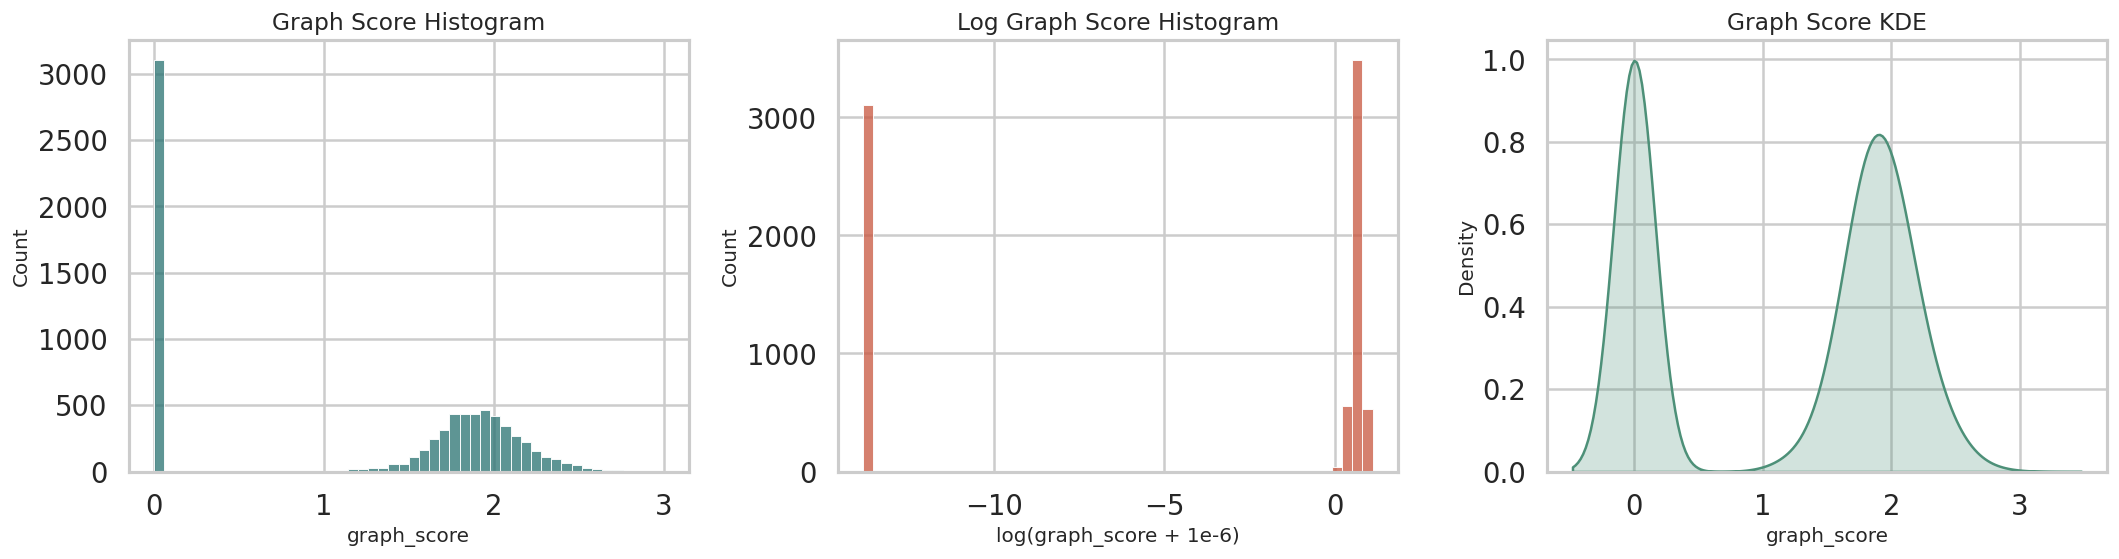

- Zero-score fraction: 0.402
- Mean=1.1479, std=0.9629, IQR=1.9598, q05=0.0000, q50=1.6853, q95=2.2804
- Possible dead-metric warning: a large spike at 0 is present.
- The score has a reasonably wide spread, which is promising for ranking or binning.


In [9]:
def describe_score_distribution(values: pd.Series) -> List[str]:
    """Generate compact interpretation bullets for score-distribution sanity checks."""
    values = values.dropna().astype(float)
    if values.empty:
        return ["No scores available."]

    zero_frac = float((values == 0).mean())
    q05, q25, q50, q75, q95 = np.quantile(values, [0.05, 0.25, 0.50, 0.75, 0.95])
    iqr = float(q75 - q25)
    std = float(values.std())
    mean = float(values.mean())
    lines = [
        f"Zero-score fraction: {zero_frac:.3f}",
        f"Mean={mean:.4f}, std={std:.4f}, IQR={iqr:.4f}, q05={q05:.4f}, q50={q50:.4f}, q95={q95:.4f}",
    ]
    if zero_frac > 0.30:
        lines.append("Possible dead-metric warning: a large spike at 0 is present.")
    if iqr < max(abs(q95), 1e-8) * 0.05:
        lines.append("Distribution looks narrow relative to its own upper tail; discriminative power may be weak.")
    if iqr >= max(abs(q95), 1e-8) * 0.15:
        lines.append("The score has a reasonably wide spread, which is promising for ranking or binning.")
    if q95 > max(q50, 1e-8) * 2.0:
        lines.append("There is a noticeable upper tail, suggesting rare higher-structure configurations.")
    return lines


score_values = graph_df["graph_score"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(score_values, bins=50, ax=axes[0], color="#287271")
axes[0].set_title("Graph Score Histogram")
axes[0].set_xlabel("graph_score")

sns.histplot(np.log(score_values + 1e-6), bins=50, ax=axes[1], color="#C8553D")
axes[1].set_title("Log Graph Score Histogram")
axes[1].set_xlabel("log(graph_score + 1e-6)")

sns.kdeplot(score_values, fill=True, ax=axes[2], color="#4D9078")
axes[2].set_title("Graph Score KDE")
axes[2].set_xlabel("graph_score")

plt.tight_layout()
plt.show()

for line in describe_score_distribution(score_values):
    print("-", line)



## 2. Decompose the score

Because the graph score is an aggregation over edges, we need to verify
whether any one component is always zero, effectively irrelevant, or so large
that it swamps the others.



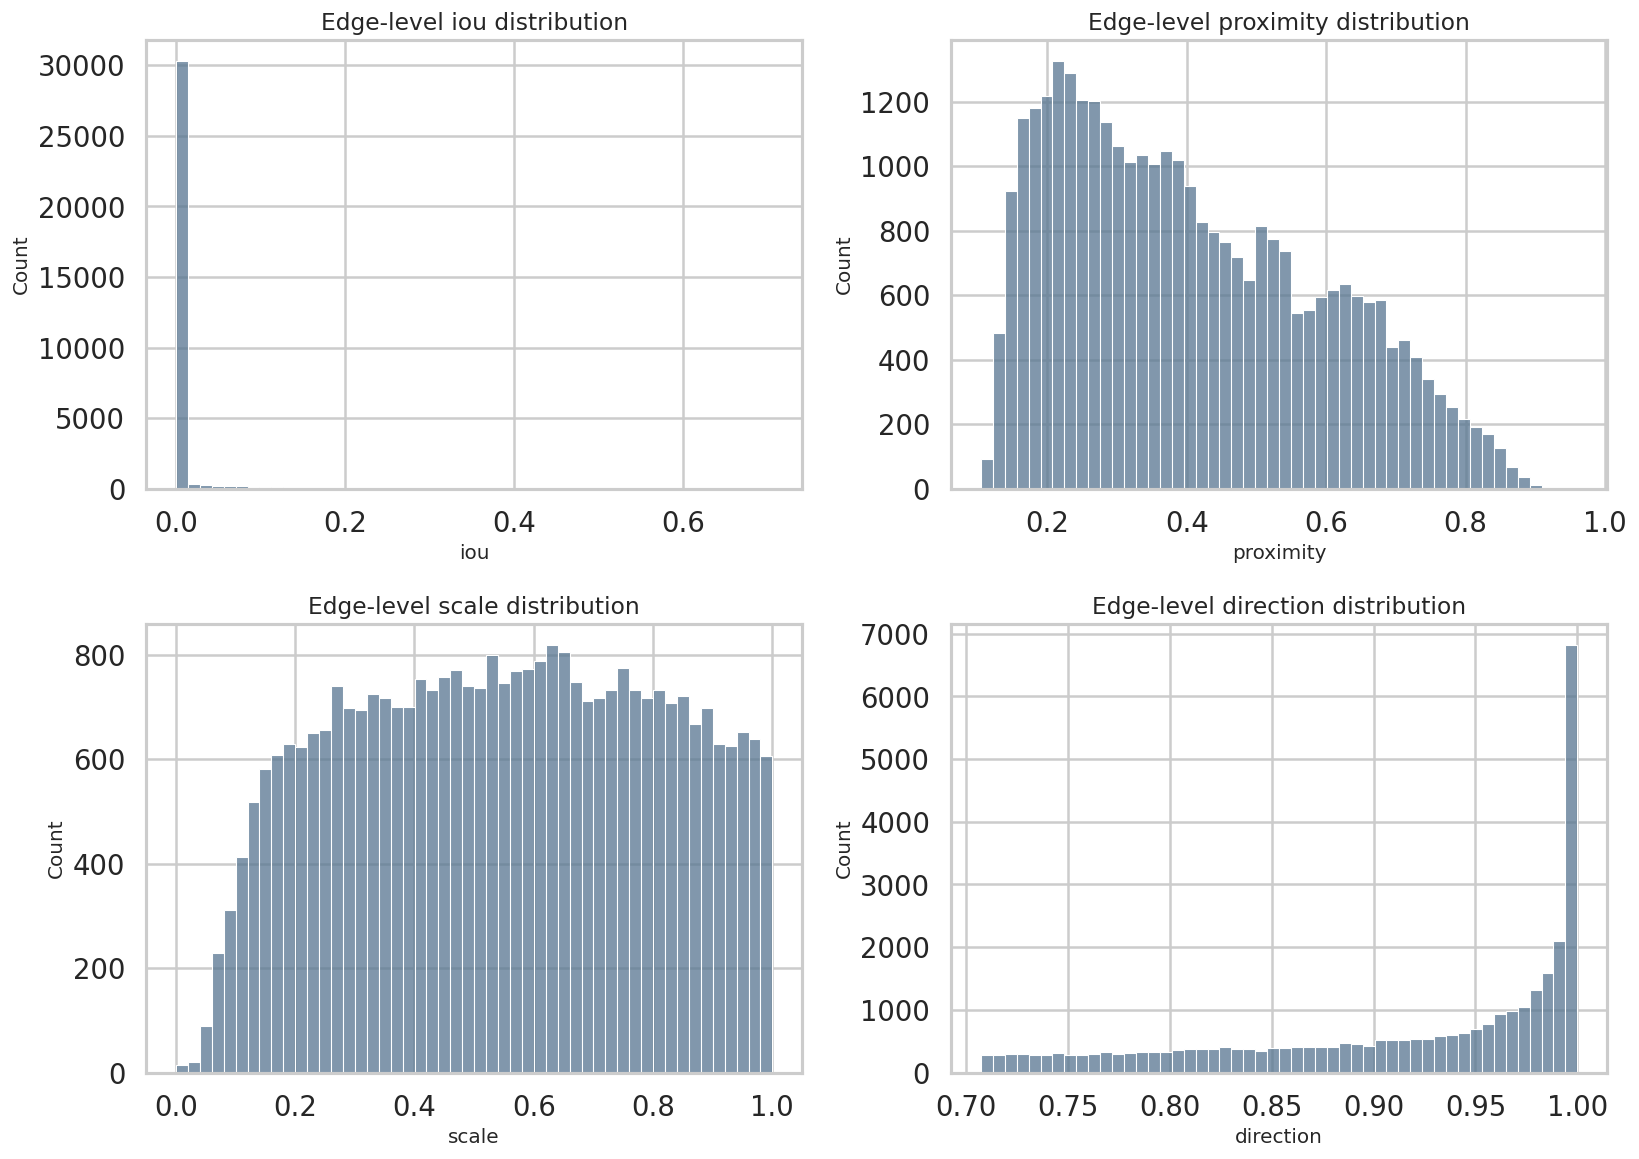

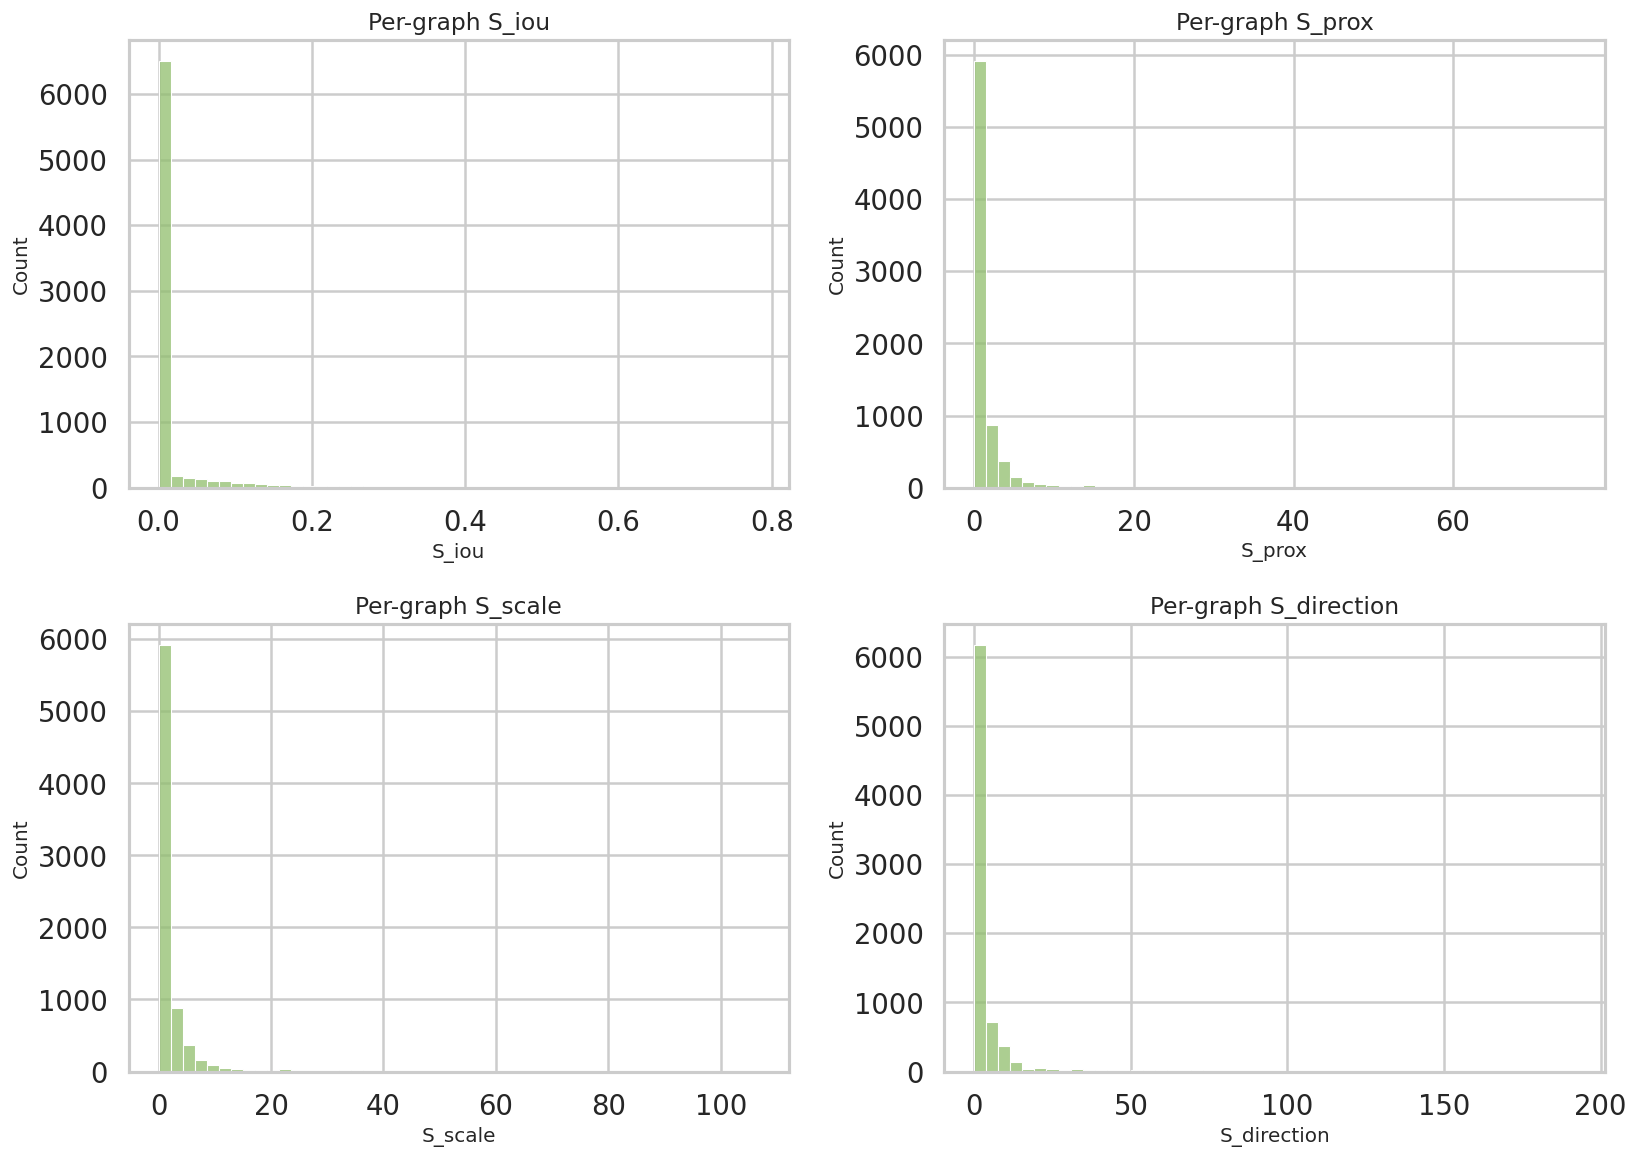

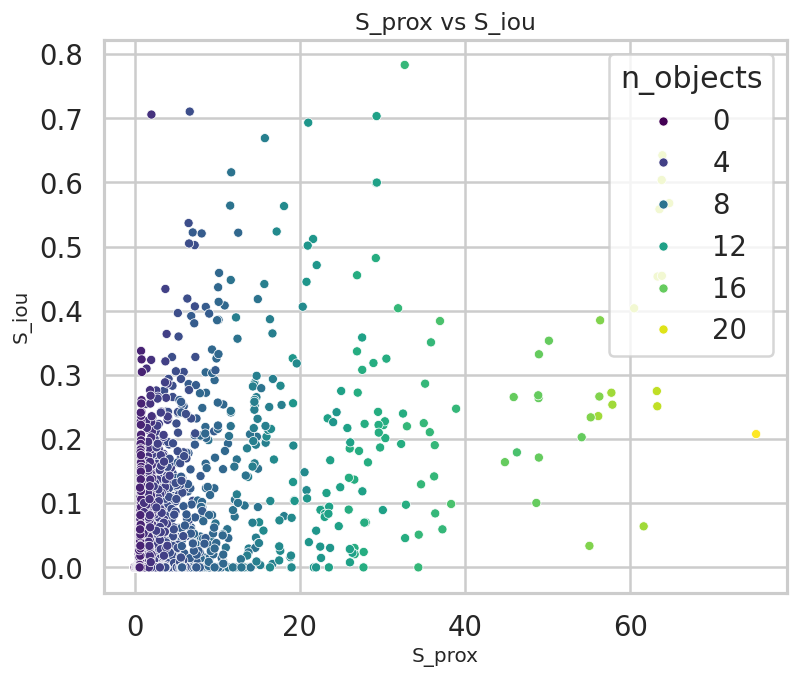

In [10]:
component_cols = ["iou", "proximity", "scale", "direction"]
weighted_cols = ["weighted_iou", "weighted_proximity", "weighted_scale", "weighted_direction"]
graph_component_cols = ["S_iou", "S_prox", "S_scale", "S_direction"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, component in zip(axes.flat, component_cols):
    sns.histplot(edge_df[component], bins=50, ax=ax, color="#577590")
    ax.set_title(f"Edge-level {component} distribution")
    ax.set_xlabel(component)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, component in zip(axes.flat, graph_component_cols):
    sns.histplot(graph_df[component], bins=50, ax=ax, color="#90BE6D")
    ax.set_title(f"Per-graph {component}")
    ax.set_xlabel(component)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.scatterplot(data=graph_df, x="S_prox", y="S_iou", hue="n_objects", palette="viridis", s=30)
plt.title("S_prox vs S_iou")
plt.tight_layout()
plt.show()



In [11]:
component_summary = pd.DataFrame(
    {
        "edge_mean": edge_df[component_cols].mean(),
        "edge_std": edge_df[component_cols].std(),
        "edge_zero_frac": (edge_df[component_cols] == 0).mean(),
    }
)
component_summary["dominance_ratio_vs_total"] = [
    graph_df[col].sum() / max(graph_df[graph_component_cols].sum().sum(), 1e-8)
    for col in graph_component_cols
]
display(component_summary)

component_corr = graph_df[graph_component_cols].corr()
display(component_corr.style.background_gradient(cmap="RdBu_r", axis=None))

for component in component_cols:
    zero_frac = float((edge_df[component] == 0).mean())
    if zero_frac > 0.95:
        print(f"- `{component}` is almost always zero ({zero_frac:.3f}).")

dominant_component = graph_df[graph_component_cols].sum().idxmax()
print(f"- Largest aggregate component across the dataset: {dominant_component}")
print("- Inspect the correlation matrix above for redundancy across graph-level components.")



,edge_mean,edge_std,edge_zero_frac,dominance_ratio_vs_total
iou,0.004658,0.023294,0.928827,0.002487
proximity,0.405048,0.186148,0.000000,0.216270
scale,0.548271,0.255043,0.000000,0.292741
direction,0.914908,0.086794,0.000000,0.488502


,S_iou,S_prox,S_scale,S_direction
S_iou,1.000000,0.575946,0.551388,0.549286
S_prox,0.575946,1.000000,0.982401,0.994313
S_scale,0.551388,0.982401,1.000000,0.987367
S_direction,0.549286,0.994313,0.987367,1.000000


- Largest aggregate component across the dataset: S_direction
- Inspect the correlation matrix above for redundancy across graph-level components.


## 3. Correlation with basic dataset properties

This checks whether the metric is mostly driven by object count, semantic
diversity, or crowdedness rather than geometry in a richer sense.



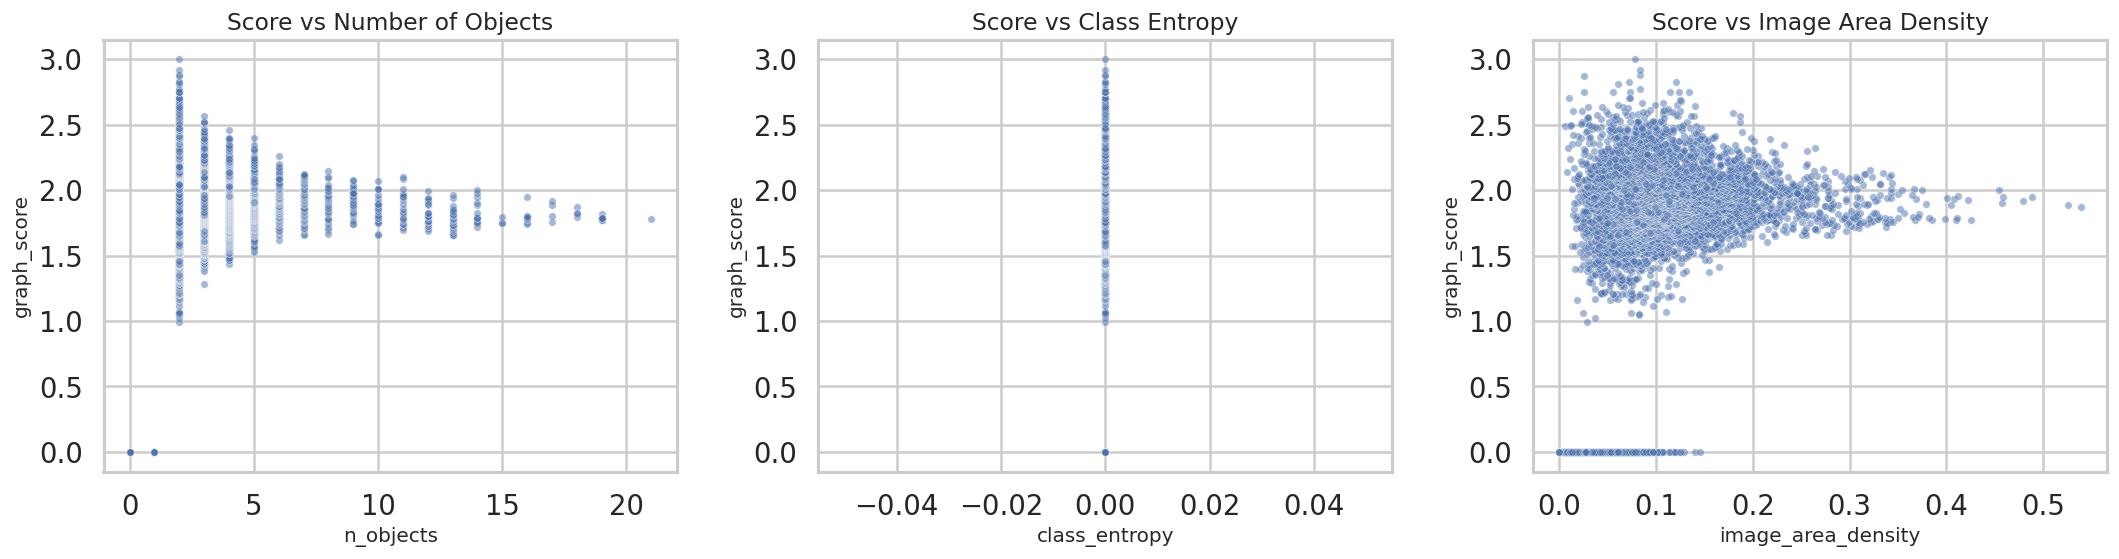

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/tmp/ipykernel_2570939/4171851796.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  out["pearson_p"] = float(stats.pearsonr(x, y).pvalue)
/tmp/ipykernel_2570939/4171851796.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  out

,pearson,spearman,pearson_p,spearman_p
score_vs_n_objects,0.547514,0.756423,0.0,0.0
score_vs_class_entropy,NaN,NaN,NaN,NaN
score_vs_density,0.582550,0.640581,0.0,0.0


In [12]:
def corr_stats(x: pd.Series, y: pd.Series) -> dict:
    """Compute Pearson and Spearman correlations with graceful fallback."""
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    out = {
        "pearson": float(x.corr(y, method="pearson")),
        "spearman": float(x.corr(y, method="spearman")),
    }
    if stats is not None:
        try:
            out["pearson_p"] = float(stats.pearsonr(x, y).pvalue)
            out["spearman_p"] = float(stats.spearmanr(x, y).pvalue)
        except Exception:
            out["pearson_p"] = np.nan
            out["spearman_p"] = np.nan
    else:
        out["pearson_p"] = np.nan
        out["spearman_p"] = np.nan
    return out


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=graph_df, x="n_objects", y="graph_score", alpha=0.5, s=20, ax=axes[0])
axes[0].set_title("Score vs Number of Objects")

sns.scatterplot(data=graph_df, x="class_entropy", y="graph_score", alpha=0.5, s=20, ax=axes[1])
axes[1].set_title("Score vs Class Entropy")

sns.scatterplot(data=graph_df, x="image_area_density", y="graph_score", alpha=0.5, s=20, ax=axes[2])
axes[2].set_title("Score vs Image Area Density")

plt.tight_layout()
plt.show()

correlation_table = pd.DataFrame(
    {
        "score_vs_n_objects": corr_stats(graph_df["n_objects"], graph_df["graph_score"]),
        "score_vs_class_entropy": corr_stats(graph_df["class_entropy"], graph_df["graph_score"]),
        "score_vs_density": corr_stats(graph_df["image_area_density"], graph_df["graph_score"]),
    }
).T
correlation_table



In [13]:
print("Interpretation helper:")
for label, row in correlation_table.iterrows():
    strength = abs(row["spearman"])
    if strength >= 0.8:
        verdict = "strong"
    elif strength >= 0.5:
        verdict = "moderate"
    else:
        verdict = "weak"
    print(f"- {label}: {verdict} Spearman correlation ({row['spearman']:.3f})")

print(
    "- In this dataset, `class_entropy` is expected to be low or even degenerate because the raw COCO annotations only expose a single `person` class."
)



Interpretation helper:
- score_vs_n_objects: moderate Spearman correlation (0.756)
- score_vs_class_entropy: weak Spearman correlation (nan)
- score_vs_density: moderate Spearman correlation (0.641)
- In this dataset, `class_entropy` is expected to be low or even degenerate because the raw COCO annotations only expose a single `person` class.


## 4. Edge-level understanding

The next plots check whether nearby objects contribute more, whether IoU is
doing any meaningful work, and whether class-pair structure exists at all.



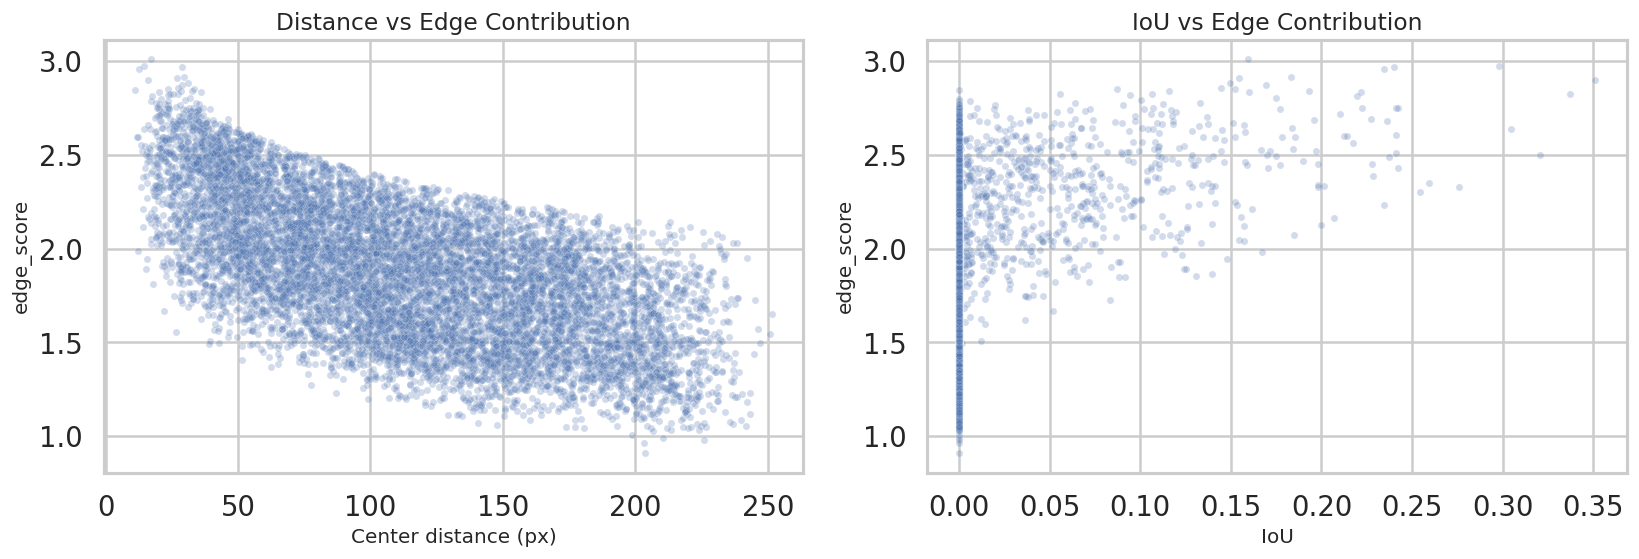

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=edge_df.sample(min(len(edge_df), 10000), random_state=SEED),
    x="center_distance_px",
    y="edge_score",
    alpha=0.25,
    s=18,
    ax=axes[0],
)
axes[0].set_title("Distance vs Edge Contribution")
axes[0].set_xlabel("Center distance (px)")

sns.scatterplot(
    data=edge_df.sample(min(len(edge_df), 10000), random_state=SEED),
    x="iou",
    y="edge_score",
    alpha=0.25,
    s=18,
    ax=axes[1],
)
axes[1].set_title("IoU vs Edge Contribution")
axes[1].set_xlabel("IoU")

plt.tight_layout()
plt.show()



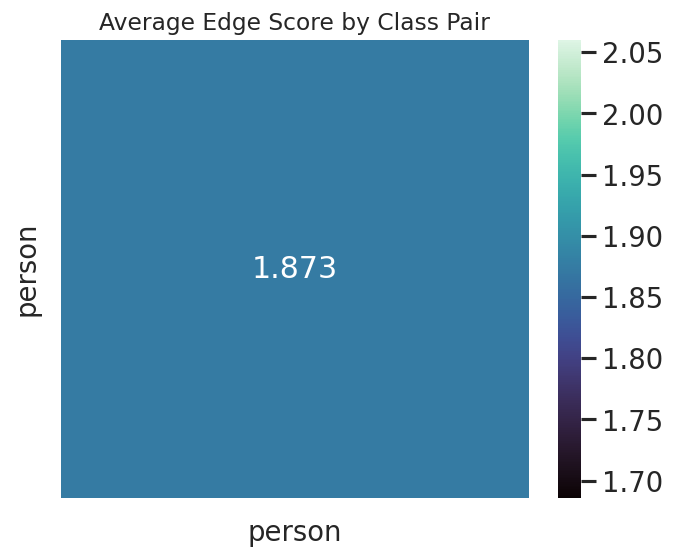

,mean_edge_score,n_edges
class_pair_str,,
person | person,1.872885,32133


- Class-pair heatmap is structurally limited here because the raw dataset has only one category: `person`.


In [15]:
pair_stats = (
    edge_df.groupby("class_pair_str")
    .agg(
        mean_edge_score=("edge_score", "mean"),
        n_edges=("edge_score", "size"),
    )
    .sort_values("n_edges", ascending=False)
)

top_pairs = pair_stats.head(MAX_CLASS_PAIRS).index.tolist()
heatmap_df = pair_stats.loc[top_pairs].copy()

if heatmap_df.empty:
    print("No class pairs available.")
else:
    labels_sorted = sorted(set(sum((pair.split(" | ") for pair in top_pairs), [])))
    matrix = pd.DataFrame(index=labels_sorted, columns=labels_sorted, dtype=float)
    for pair_name, row in heatmap_df.iterrows():
        a, b = pair_name.split(" | ")
        matrix.loc[a, b] = row["mean_edge_score"]
        matrix.loc[b, a] = row["mean_edge_score"]
    matrix = matrix.fillna(0.0)

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt=".3f", cmap="mako")
    plt.title("Average Edge Score by Class Pair")
    plt.tight_layout()
    plt.show()

    display(heatmap_df)

if object_df["label"].nunique() == 1:
    print("- Class-pair heatmap is structurally limited here because the raw dataset has only one category: `person`.")



## 5. Graph-level visualization

These grids are the most important practical check. They let you verify
whether high-score and low-score scenes really look structurally different.



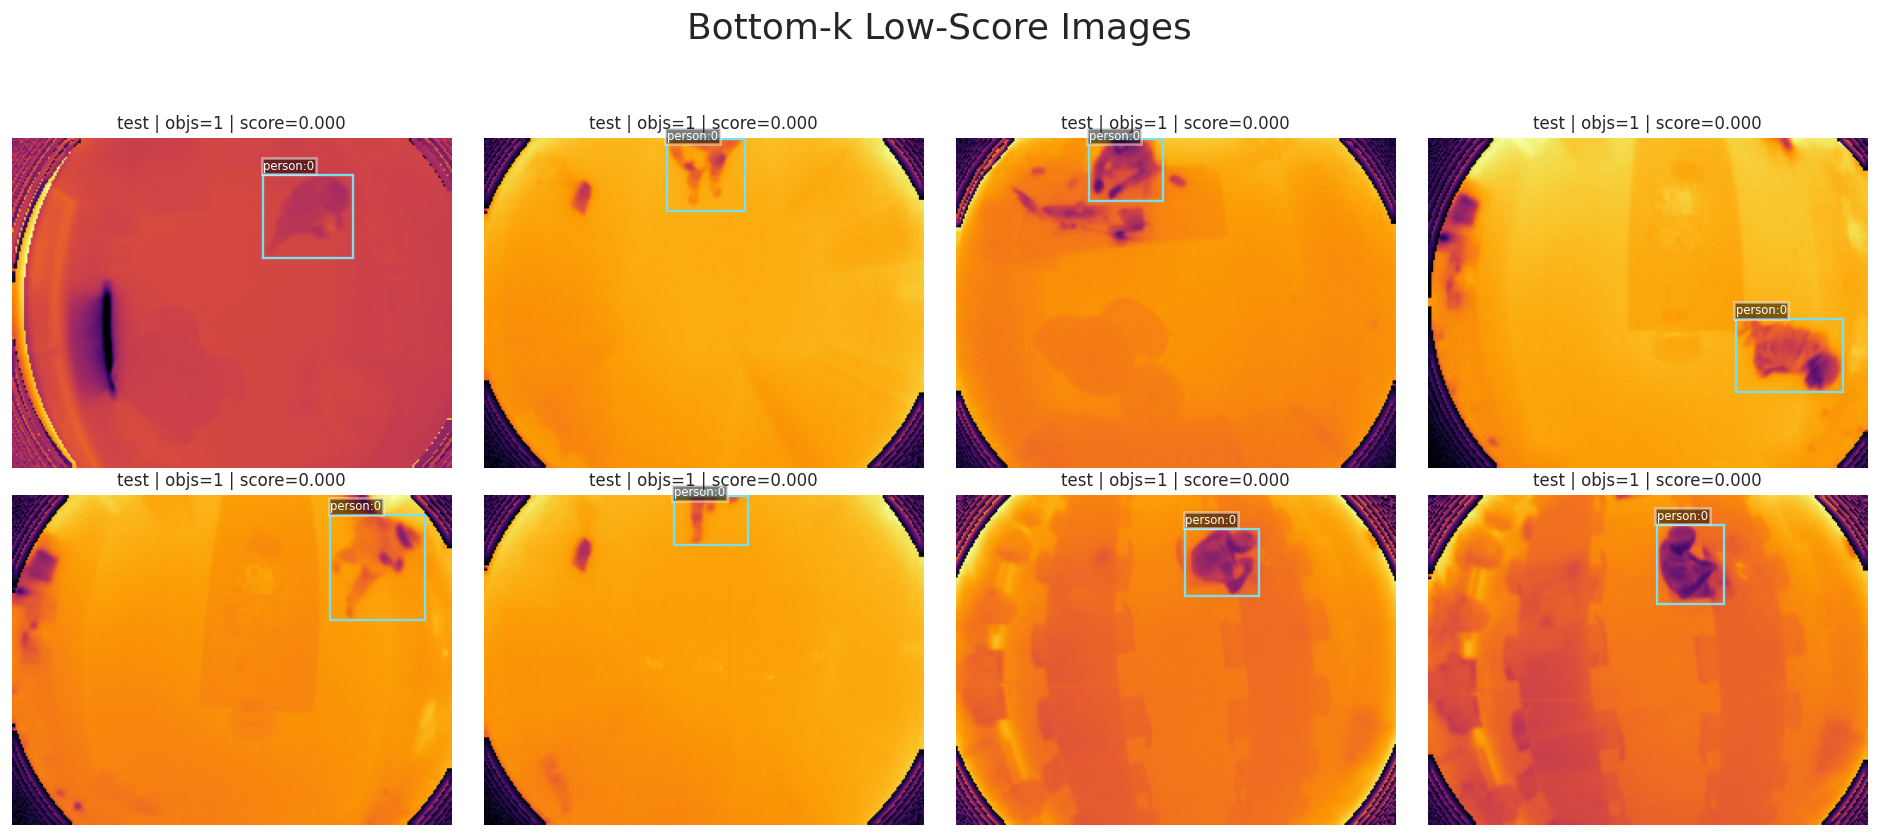

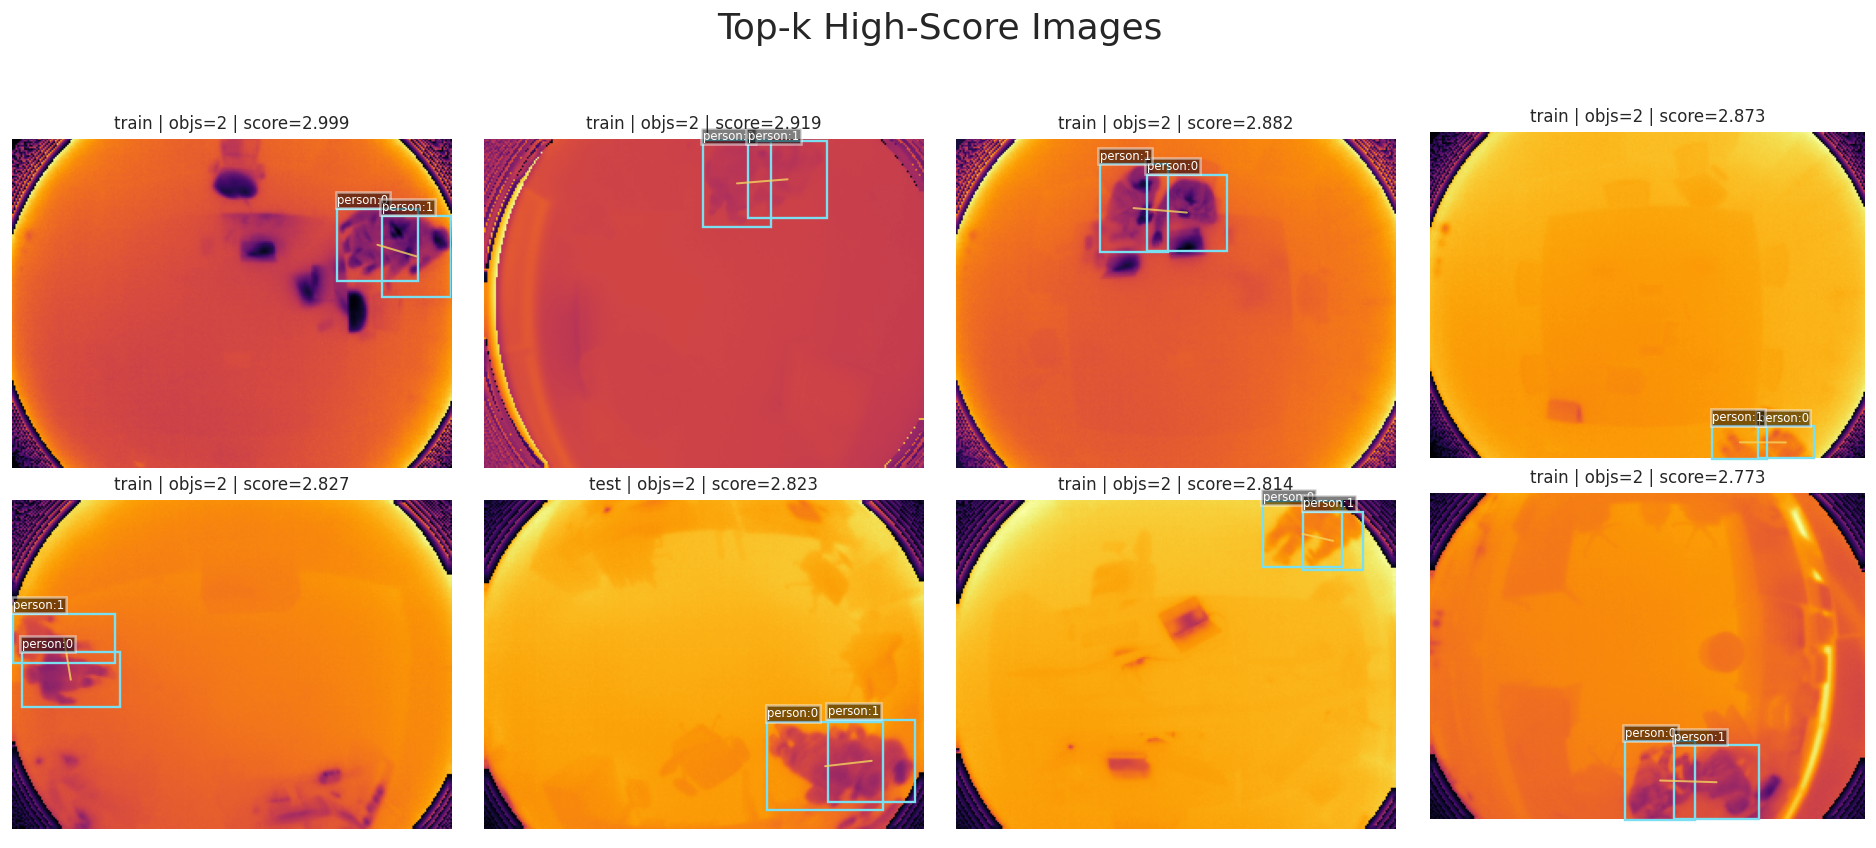

In [16]:
def load_image_and_objects(image_key: str) -> Tuple[np.ndarray, pd.DataFrame]:
    """Load one image and its object rows."""
    row = graph_df.set_index("image_key").loc[image_key]
    img = load_uint16_npy_image(Path(row["image_path"]))
    objs = object_df.query("image_key == @image_key").copy()
    return img, objs


def draw_scene(
    ax: plt.Axes,
    image_key: str,
    *,
    annotate_labels: bool = True,
    draw_edges: bool = True,
    max_edges: int = TOP_EDGES_TO_DRAW,
) -> None:
    """Render one scene with bounding boxes and optionally strongest edges."""
    row = graph_df.set_index("image_key").loc[image_key]
    image, objs = load_image_and_objects(image_key)
    ax.imshow(normalize_for_display(image), cmap="inferno")
    ax.set_axis_off()
    ax.set_title(
        f"{row['split']} | objs={int(row['n_objects'])} | score={row['graph_score']:.3f}",
        fontsize=10,
    )

    for obj in objs.itertuples(index=False):
        rect = patches.Rectangle(
            (obj.x1, obj.y1),
            obj.x2 - obj.x1,
            obj.y2 - obj.y1,
            linewidth=1.4,
            edgecolor="#7BDFF2",
            facecolor="none",
        )
        ax.add_patch(rect)
        if annotate_labels:
            ax.text(
                obj.x1,
                max(0, obj.y1 - 3),
                f"{obj.label}:{obj.obj_idx}",
                color="white",
                fontsize=7,
                bbox={"facecolor": "black", "alpha": 0.5, "pad": 1},
            )

    if draw_edges and not edge_df.empty:
        edges = (
            edge_df.query("image_key == @image_key")
            .sort_values("edge_score", ascending=False)
            .head(max_edges)
        )
        lookup = objs.set_index("obj_idx")
        for edge in edges.itertuples(index=False):
            if edge.source_obj_idx not in lookup.index or edge.target_obj_idx not in lookup.index:
                continue
            src = lookup.loc[edge.source_obj_idx]
            dst = lookup.loc[edge.target_obj_idx]
            x_values = [src.cx, dst.cx]
            y_values = [src.cy, dst.cy]
            ax.plot(x_values, y_values, color="#F4D35E", linewidth=1.2, alpha=0.8)


def show_image_grid(rows: pd.DataFrame, title: str, ncols: int = 4) -> None:
    """Display a grid of scenes for quick visual inspection."""
    if rows.empty:
        print(f"No images available for: {title}")
        return
    keys = rows["image_key"].tolist()
    nrows = int(math.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, key in zip(axes, keys):
        draw_scene(ax, key)
    for ax in axes[len(keys):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


low_examples = graph_df.nsmallest(TOP_K, "graph_score")
high_examples = graph_df.nlargest(TOP_K, "graph_score")

show_image_grid(low_examples, title="Bottom-k Low-Score Images")
show_image_grid(high_examples, title="Top-k High-Score Images")



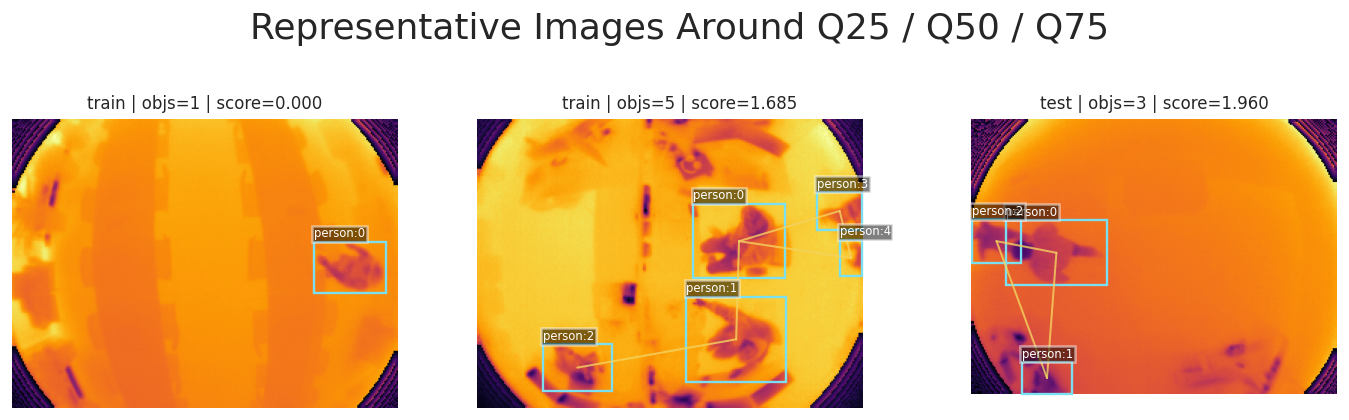

In [17]:
quantiles = {"Q25": 0.25, "Q50": 0.50, "Q75": 0.75}
representative_rows = []
for name, q in quantiles.items():
    target = graph_df["graph_score"].quantile(q)
    candidate = graph_df.iloc[(graph_df["graph_score"] - target).abs().argsort()[:1]].copy()
    candidate["quantile_label"] = name
    representative_rows.append(candidate)

quantile_examples = pd.concat(representative_rows, ignore_index=True)
show_image_grid(quantile_examples, title="Representative Images Around Q25 / Q50 / Q75", ncols=3)



## 6. Binning feasibility

This section tests whether quantile bins are balanced and whether visual
samples from each bin appear coherent rather than arbitrary.



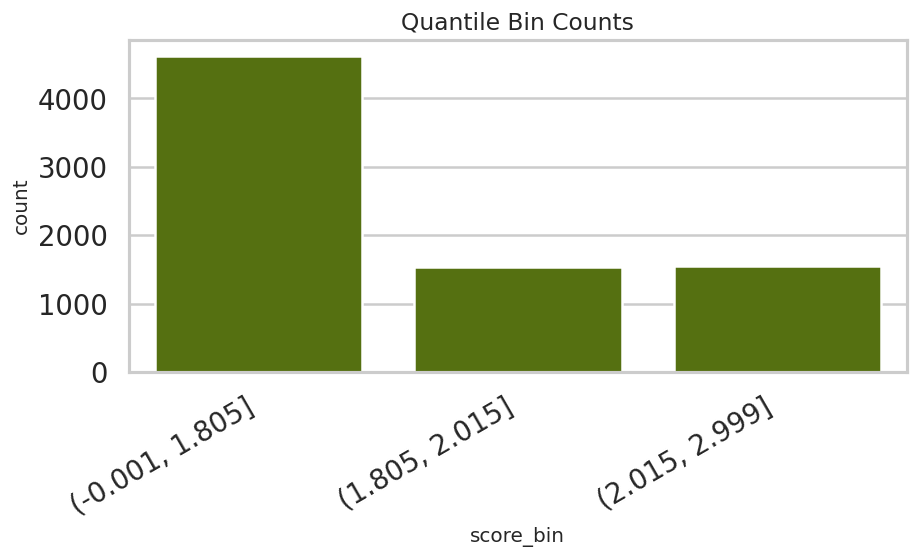

score_bin
(-0.001, 1.805]    4627
(1.805, 2.015]     1542
(2.015, 2.999]     1543
Name: count, dtype: int64

In [18]:
graph_df = graph_df.copy()
graph_df["score_bin"] = pd.qcut(
    graph_df["graph_score"],
    q=5,
    duplicates="drop",
)

plt.figure(figsize=(8, 5))
sns.countplot(data=graph_df, x="score_bin", color="#5C8001")
plt.xticks(rotation=30, ha="right")
plt.title("Quantile Bin Counts")
plt.tight_layout()
plt.show()

display(graph_df["score_bin"].value_counts().sort_index())



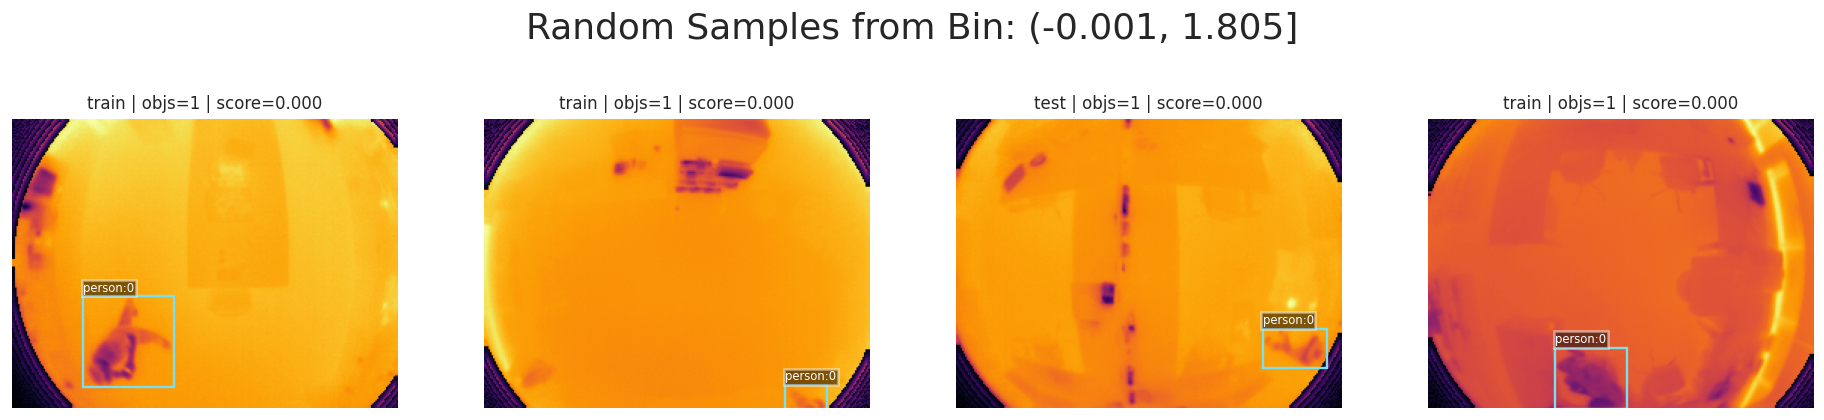

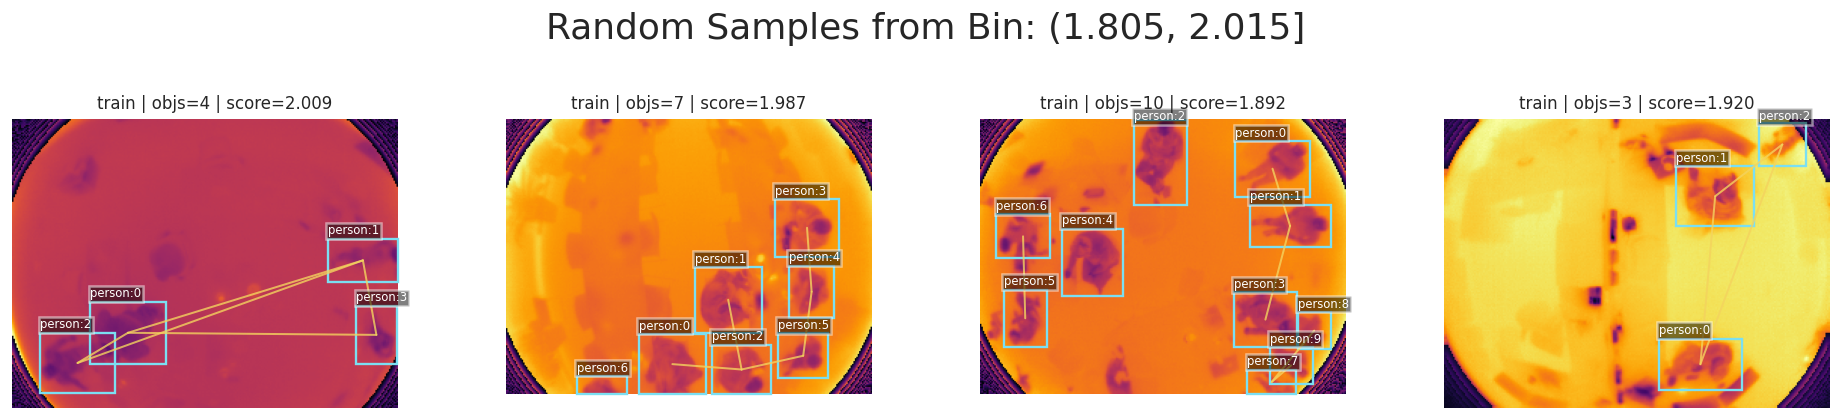

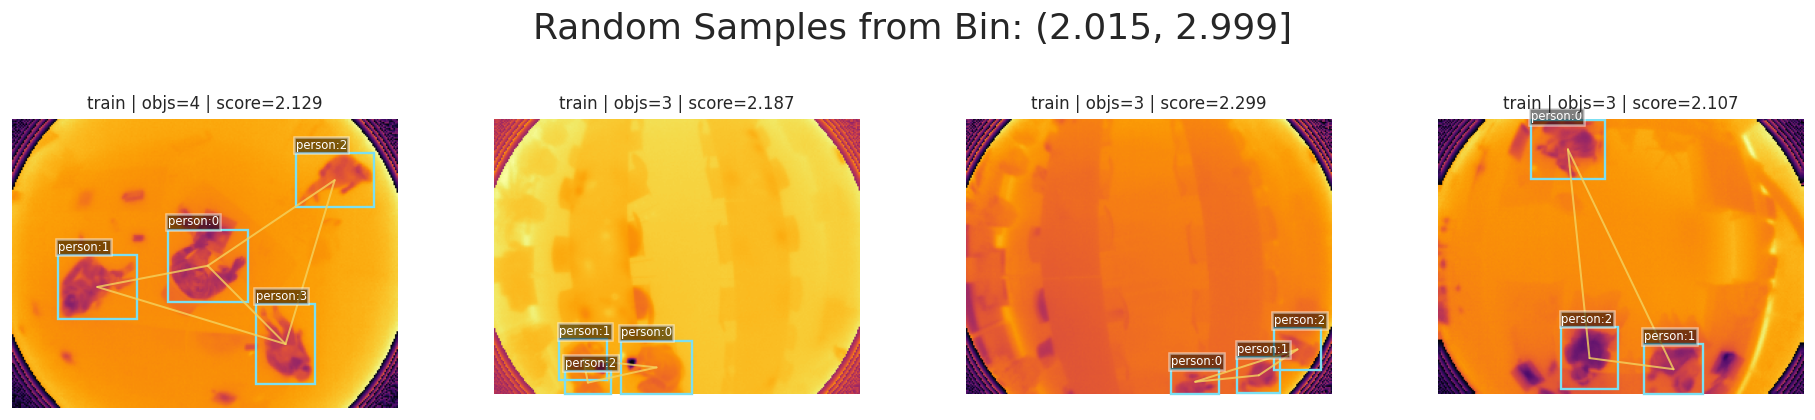

,n_images,mean_score,score_iqr,mean_objects,mean_density
score_bin,,,,,
"(-0.001, 1.805]",4627,0.542565,1.578760,1.873568,0.061497
"(1.805, 2.015]",1542,1.910906,0.100985,3.977302,0.126569
"(2.015, 2.999]",1543,2.200453,0.202457,2.905379,0.109845


In [19]:
for score_bin, group in graph_df.groupby("score_bin", observed=False):
    sampled = group.sample(min(SAMPLE_PER_BIN, len(group)), random_state=SEED)
    show_image_grid(sampled, title=f"Random Samples from Bin: {score_bin}", ncols=SAMPLE_PER_BIN)

bin_summary = (
    graph_df.groupby("score_bin", observed=False)
    .agg(
        n_images=("image_key", "size"),
        mean_score=("graph_score", "mean"),
        score_iqr=("graph_score", lambda s: float(s.quantile(0.75) - s.quantile(0.25))),
        mean_objects=("n_objects", "mean"),
        mean_density=("image_area_density", "mean"),
    )
)
bin_summary



In [20]:
print("Binning interpretation helper:")
if graph_df["score_bin"].nunique() >= 4 and graph_df["score_bin"].value_counts().min() > 0:
    print("- Quantile bins are populated, which is a good sign for downstream stratified sampling.")
else:
    print("- Some bins collapsed or are empty; score-based binning may be unreliable.")
print("- Use the grids above to judge whether bins look semantically coherent or mostly random.")



Binning interpretation helper:
- Some bins collapsed or are empty; score-based binning may be unreliable.
- Use the grids above to judge whether bins look semantically coherent or mostly random.


## 7. Relation-level analysis

No explicit relation annotations were found in the raw v18 COCO files, so the
relation analysis below uses a clearly labeled **derived geometry taxonomy**.



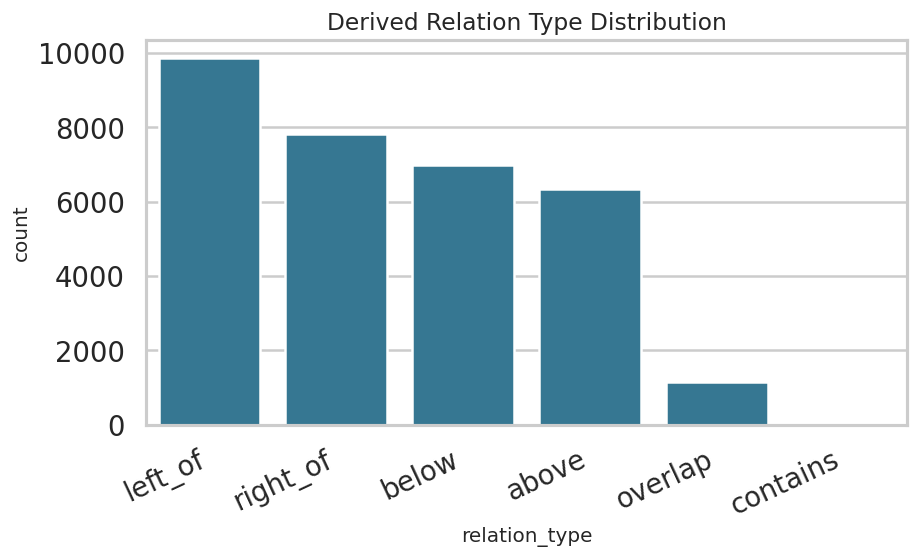

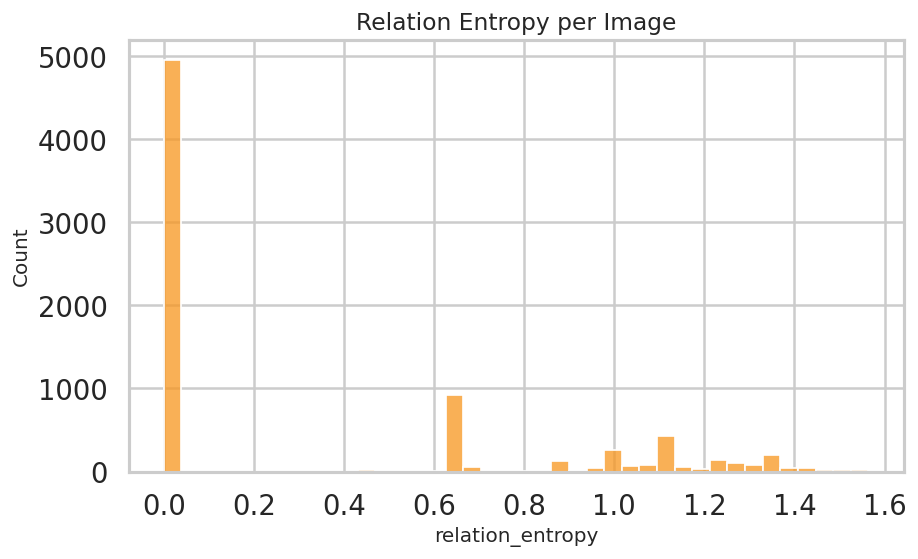

,count
relation_type,
left_of,9861
right_of,7821
below,6976
above,6332
overlap,1141
contains,2


In [21]:
relation_counts = edge_df["relation_type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=relation_counts.index, y=relation_counts.values, color="#277DA1")
plt.xticks(rotation=25, ha="right")
plt.title("Derived Relation Type Distribution")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(graph_df["relation_entropy"], bins=40, color="#F8961E")
plt.title("Relation Entropy per Image")
plt.xlabel("relation_entropy")
plt.tight_layout()
plt.show()

display(relation_counts.to_frame("count"))



## 8. Embedding the graphs

We build a graph-level feature vector from relation histograms, object-count
statistics, density, and score components, then reduce it to 2D with UMAP if
available, otherwise TSNE.



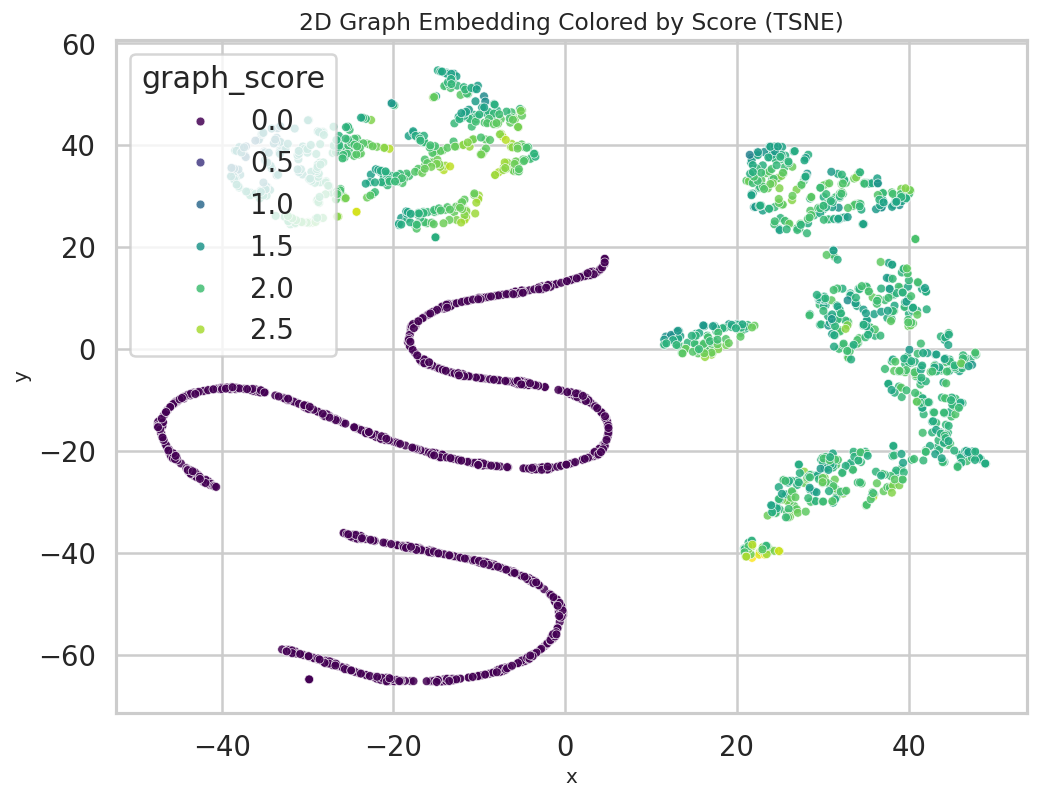

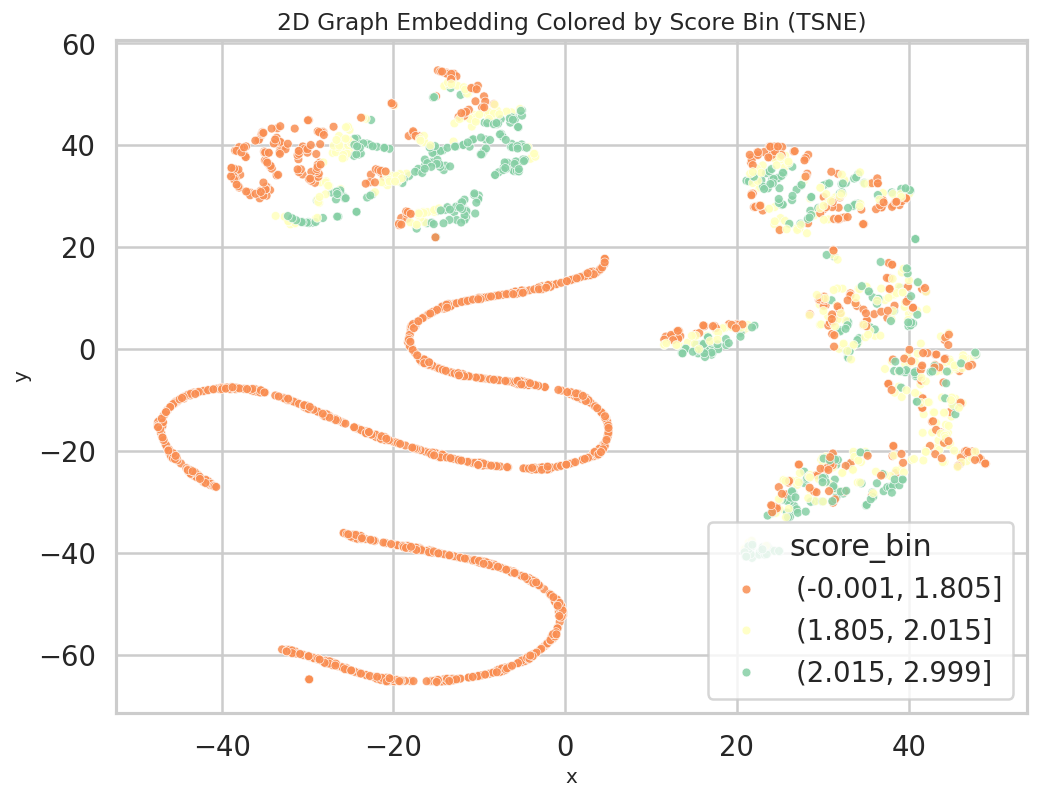

- Inspect whether nearby points share score ranges or bins; if they do, the scalar score is more likely to align with a real structural manifold.


In [22]:
relation_hist = pd.crosstab(edge_df["image_key"], edge_df["relation_type"]).reindex(
    graph_df["image_key"], fill_value=0
)
relation_hist.columns = [f"rel_{c}" for c in relation_hist.columns]

feature_df = (
    graph_df.set_index("image_key")[
        [
            "graph_score",
            "graph_score_raw_sum",
            "graph_score_mean",
            "S_iou",
            "S_prox",
            "S_scale",
            "S_direction",
            "n_objects",
            "n_edges",
            "class_entropy",
            "image_area_density",
            "relation_entropy",
        ]
    ]
    .join(relation_hist, how="left")
    .fillna(0.0)
)

embedding_input = feature_df.copy()
if len(embedding_input) > EMBEDDING_MAX_POINTS:
    sampled_keys = graph_df.sample(EMBEDDING_MAX_POINTS, random_state=SEED)["image_key"]
    embedding_input = embedding_input.loc[sampled_keys]

X = embedding_input.to_numpy(dtype=np.float32)
if StandardScaler is not None:
    X = StandardScaler().fit_transform(X)

embedding_model_name = None
embedding_2d = None
if len(embedding_input) >= 10:
    if umap is not None:
        embedding_model_name = "UMAP"
        reducer = umap.UMAP(random_state=SEED, n_neighbors=20, min_dist=0.15)
        embedding_2d = reducer.fit_transform(X)
    elif TSNE is not None:
        embedding_model_name = "TSNE"
        perplexity = min(30, max(5, len(embedding_input) // 30))
        reducer = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, init="pca")
        embedding_2d = reducer.fit_transform(X)

if embedding_2d is None:
    print("Skipping embedding: UMAP/TSNE unavailable or not enough samples.")
else:
    embedding_plot_df = embedding_input.reset_index()[["image_key"]].copy()
    embedding_plot_df["x"] = embedding_2d[:, 0]
    embedding_plot_df["y"] = embedding_2d[:, 1]
    embedding_plot_df = embedding_plot_df.merge(
        graph_df[["image_key", "graph_score", "score_bin"]],
        on="image_key",
        how="left",
    )

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=embedding_plot_df,
        x="x",
        y="y",
        hue="graph_score",
        palette="viridis",
        s=28,
        alpha=0.85,
    )
    plt.title(f"2D Graph Embedding Colored by Score ({embedding_model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=embedding_plot_df,
        x="x",
        y="y",
        hue="score_bin",
        palette="Spectral",
        s=28,
        alpha=0.85,
    )
    plt.title(f"2D Graph Embedding Colored by Score Bin ({embedding_model_name})")
    plt.tight_layout()
    plt.show()

    print("- Inspect whether nearby points share score ranges or bins; if they do, the scalar score is more likely to align with a real structural manifold.")



## 9. Robustness of the metric

Small random perturbations should change the score somewhat, but not destroy
the ranking if the metric is reasonably stable.



In [23]:
def perturb_box(box: Sequence[float], width: int, height: int, rng_obj: np.random.Generator) -> List[float]:
    """Apply a small random perturbation to a box while keeping it valid."""
    x1, y1, x2, y2 = map(float, box)
    w = max(x2 - x1, 1.0)
    h = max(y2 - y1, 1.0)
    std_x = max(PERTURBATION_STD_FRACTION * w, 1.0)
    std_y = max(PERTURBATION_STD_FRACTION * h, 1.0)

    nx1 = np.clip(x1 + rng_obj.normal(0, std_x), 0, width - 2)
    ny1 = np.clip(y1 + rng_obj.normal(0, std_y), 0, height - 2)
    nx2 = np.clip(x2 + rng_obj.normal(0, std_x), nx1 + 1, width - 1e-6)
    ny2 = np.clip(y2 + rng_obj.normal(0, std_y), ny1 + 1, height - 1e-6)
    return [float(nx1), float(ny1), float(nx2), float(ny2)]


def recompute_graph_score_for_objects(objects: pd.DataFrame, width: int, height: int, rng_obj: np.random.Generator) -> float:
    """Recompute the graph score after perturbing all boxes in one image."""
    if len(objects) < 2:
        return 0.0

    perturbed_scores = []
    for (_, obj_a), (_, obj_b) in combinations(objects.iterrows(), 2):
        box_a = perturb_box(obj_a[["x1", "y1", "x2", "y2"]].tolist(), width, height, rng_obj)
        box_b = perturb_box(obj_b[["x1", "y1", "x2", "y2"]].tolist(), width, height, rng_obj)
        perturbed_scores.append(score_edge(box_a, box_b, image_size=(width, height))["edge_score"])

    if not perturbed_scores:
        return 0.0
    raw = float(np.sum(perturbed_scores))
    return raw if GRAPH_SCORE_NORMALIZATION == "sum" else float(np.mean(perturbed_scores))


robustness_subset = graph_df.sample(min(ROBUSTNESS_SAMPLE_SIZE, len(graph_df)), random_state=SEED).copy()
robustness_rows = []
for row in robustness_subset.itertuples(index=False):
    objs = object_df.query("image_key == @row.image_key").copy()
    perturbed_score = recompute_graph_score_for_objects(objs, row.width, row.height, rng)
    delta = perturbed_score - row.graph_score
    robustness_rows.append(
        {
            "image_key": row.image_key,
            "original_score": row.graph_score,
            "perturbed_score": perturbed_score,
            "abs_delta": abs(delta),
            "rel_delta": abs(delta) / max(abs(row.graph_score), 1e-6),
        }
    )

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.head()



,image_key,original_score,perturbed_score,abs_delta,rel_delta
0,train:sequence-20250212-162944-757694-ce33dc-6...,1.992455,1.899961,0.092493,0.046422
1,train:sequence-20250228-133256-990282-94b4c8-6...,0.000000,0.000000,0.000000,0.000000
2,train:sequence-20250303-161927-191093-94f1d9-6...,1.754463,1.755372,0.000909,0.000518
3,train:sequence-20250324-162422-205564-984cb1-a...,1.537010,1.530608,0.006402,0.004165
4,train:sequence-20250227-155519-988374-985a55-e...,2.464035,2.478138,0.014103,0.005724


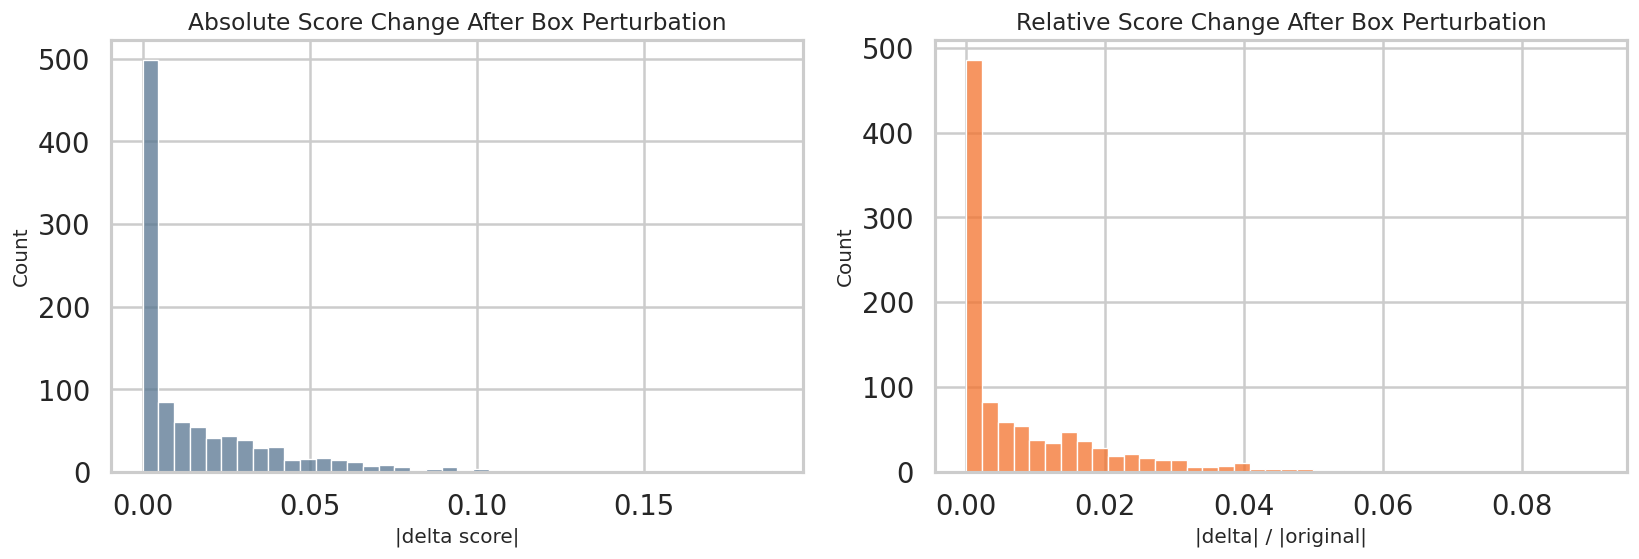

{'mean_abs_delta': 0.01598478196457334,
 'median_abs_delta': 0.004827420879148225,
 'mean_rel_delta': 0.008168076345937162,
 'median_rel_delta': 0.0026182534077375495,
 'spearman_rank_corr': 0.9973499044729406}

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(robustness_df["abs_delta"], bins=40, ax=axes[0], color="#577590")
axes[0].set_title("Absolute Score Change After Box Perturbation")
axes[0].set_xlabel("|delta score|")

sns.histplot(robustness_df["rel_delta"], bins=40, ax=axes[1], color="#F3722C")
axes[1].set_title("Relative Score Change After Box Perturbation")
axes[1].set_xlabel("|delta| / |original|")

plt.tight_layout()
plt.show()

rank_corr = float(
    robustness_df["original_score"].corr(robustness_df["perturbed_score"], method="spearman")
)
robustness_summary = {
    "mean_abs_delta": float(robustness_df["abs_delta"].mean()),
    "median_abs_delta": float(robustness_df["abs_delta"].median()),
    "mean_rel_delta": float(robustness_df["rel_delta"].mean()),
    "median_rel_delta": float(robustness_df["rel_delta"].median()),
    "spearman_rank_corr": rank_corr,
}
robustness_summary



## 10. Final usability checklist


This cell combines the earlier diagnostics into a compact summary. Some items
can be judged automatically, while others still require visual inspection of
the image grids above.



In [25]:
def verdict(flag: bool) -> str:
    return "yes" if flag else "no"


score_q = graph_df["graph_score"].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
wide_distribution = (score_q.loc[0.75] - score_q.loc[0.25]) > max(score_q.loc[0.95], 1e-8) * 0.10
nontrivial = float((graph_df["graph_score"] == 0).mean()) < 0.30 and graph_df["graph_score"].std() > 1e-6
nonredundant = (
    graph_df[graph_component_cols].corr().where(~np.eye(len(graph_component_cols), dtype=bool)).abs().max().max()
    < 0.98
)
not_mainly_count = abs(correlation_table.loc["score_vs_n_objects", "spearman"]) < 0.80
not_mainly_density = abs(correlation_table.loc["score_vs_density", "spearman"]) < 0.80
bin_friendly = graph_df["score_bin"].value_counts().min() > 0 if "score_bin" in graph_df else False
robust_enough = rank_corr > 0.80

checklist = pd.DataFrame(
    [
        ("widely_distributed", verdict(wide_distribution), "based on score IQR vs upper tail"),
        ("nontrivial", verdict(nontrivial), "based on zero-mass and score variance"),
        ("visually_meaningful", "manual review", "inspect top/bottom/Q25-Q75 grids above"),
        ("nonredundant", verdict(nonredundant), "based on graph-component correlation"),
        ("not_mostly_object_count", verdict(not_mainly_count), "based on score vs n_objects"),
        ("not_mostly_density", verdict(not_mainly_density), "based on score vs density"),
        ("bin_friendly", verdict(bin_friendly), "based on qcut bin occupancy"),
        ("reasonably_robust", verdict(robust_enough), "based on perturbation rank correlation"),
    ],
    columns=["criterion", "status", "notes"],
)
checklist



,criterion,status,notes
0,widely_distributed,yes,based on score IQR vs upper tail
1,nontrivial,no,based on zero-mass and score variance
2,visually_meaningful,manual review,inspect top/bottom/Q25-Q75 grids above
3,nonredundant,no,based on graph-component correlation
4,not_mostly_object_count,yes,based on score vs n_objects
5,not_mostly_density,yes,based on score vs density
6,bin_friendly,yes,based on qcut bin occupancy
7,reasonably_robust,yes,based on perturbation rank correlation


In [26]:
display(Markdown("### Summary"))
for row in checklist.itertuples(index=False):
    print(f"- {row.criterion}: {row.status} ({row.notes})")

print("\nRepo-specific caveats:")
print("- `val/annotations.json` currently references many images not present locally; this notebook only scores matched local `.npy` files.")
print("- The raw COCO schema currently exposes a single `person` class, so class-entropy and class-pair analyses have limited semantic range.")
print("- Relation analysis is derived from box geometry because no raw relation annotations were found.")




### Summary

- widely_distributed: yes (based on score IQR vs upper tail)
- nontrivial: no (based on zero-mass and score variance)
- visually_meaningful: manual review (inspect top/bottom/Q25-Q75 grids above)
- nonredundant: no (based on graph-component correlation)
- not_mostly_object_count: yes (based on score vs n_objects)
- not_mostly_density: yes (based on score vs density)
- bin_friendly: yes (based on qcut bin occupancy)
- reasonably_robust: yes (based on perturbation rank correlation)

Repo-specific caveats:
- `val/annotations.json` currently references many images not present locally; this notebook only scores matched local `.npy` files.
- The raw COCO schema currently exposes a single `person` class, so class-entropy and class-pair analyses have limited semantic range.
- Relation analysis is derived from box geometry because no raw relation annotations were found.
